# ATF2 EXT + FFS の軌道補正(実行用)

`orbit_correction_clean.ipynb` の本編から、**軌道補正に必要な部分だけ**を取り出したノート。上から実行すると、
1. 誤差(四重極の架台の据付誤差)を入れた加速器を作り、
2. その加速器の上で応答行列 R を測り、Δu = −R⁺ r でノブ(コレクタ・ムーバー)を動かす補正を、**補正できるまでくり返す**(上限つき)。
3. seed 1 本の補正の様子と、**複数 seed** のまとめ(ノブ、BPM ごとの読み値、軌道、四重極の最終位置、ムーバーの範囲)を図にする。

- 誤差の大きさ・seed・くり返しの上限などは、**1 章の「設定」のセルだけ**を変える。
- 関数の中身の確かめ(単位、RF-Track の API の挙動、R が変わる理由など)は、検証用のノート `orbit_correction_checks.ipynb` にまとめてある。各章の説明・考察の元の版は `orbit_correction_clean.ipynb`。
- カーネル: flight(RF-Track 2.6.3)。計算時間の目安: σ = 100 µm、20 seed、R を毎回測り直し、R は P1・読み値は B0 の設定で約 1 時間。
- **ビームの使い分け**: R は 1 粒子 `P1` で測り、補正に使う読み値と評価はすべて 10000 粒子の `B0`(の重心)で行う。実機の BPM が読むのはビームの重心で、B0 の重心は設計の加速器でも FFS で最大 16 µm ずれるため(P1 では見えない)。R は P1 と B0 で 0.3% 以下しか違わず、P1 なら約 200 倍速い(検証ノート A.12)。

## 補正の流れ
```
 誤差を入れる(seed ごとに配置が変わる)
        │
        ▼
 R を測る ──► 読む r ──► Δu = −R⁺ r をノブに足す ──► track ──┐
   ▲                                                         │
   └──── (REMEASURE_R = True なら毎回)  補正できるまでくり返す ◄──┘
```
「補正できた」= 粒子が終点まで届き、使う BPM の読み値の rms が x, y とも `CONV_MM` 未満で、前の回からの変化が `CONV_REL` 未満(下限に達した)。

# 1. 設定
ここだけを変えて、上から実行する。

In [2]:
SIGMA_GIRDER_MM = 0.1           # 四重極の架台の据付誤差 σ [mm](0.1 = 100 µm)
SIGMA_BPM_MM    = 0.0           # BPM 自身の取付誤差 δ の σ [mm]
SEED_ONE        = 1             # 2 章〜5 章で 1 本だけ詳しく見る seed
SEEDS           = list(range(1, 21))   # 6 章で補正する seed
N_MAX           = 100           # くり返しの上限 [回]
REMEASURE_R     = True          # True: 2 回目から毎回、今の加速器で R を測り直す / False: seed の最初の R を使い続ける
R_BUNCH         = 'P1'          # R を測るビーム: 'P1'(1 粒子。速い)/ 'B0'(10000 粒子。R 1 回 約 3 分)。P1 と B0 の R の差は 0.3% 以下(検証ノート A.12)
READ_BUNCH      = 'B0'          # 補正に使う読み値と評価(軌道、ビーム − 磁場中心、届いた粒子)に使うビーム。実機の BPM はビームの重心を読むので B0
COMPARE_FIXED_R = False         # True: 5 章で、R を使い続ける場合も参考に計算する(READ_BUNCH = 'B0' だと 20 seed で約 2 時間)
CONV_MM         = 0.1           # 補正できた: 読み値の rms がこれ未満 [mm]
CONV_REL        = 0.01          # 補正できた: 前の回からの変化がこの割合未満
MOVER_LIMIT_MM  = 1.0           # ムーバーの動く範囲 [mm](x, y それぞれ。据付位置からの移動量にかかるとする。値は要確認)

# 2. 準備と道具
`orbit_correction_clean.ipynb` の 1, 2, 4 章と同じ定義(ラティス、ビーム、使う BPM、読む・動かす・誤差を入れる関数、ノブ)。

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft

TWISS = ('/Users/hasas/ATF/RF_Track/flight-simulator-master/Interfaces/'
         'ATF2/Ext_ATF2/ATF2_EXT_FF_v5.2.twiss')

def load_lattice_default():
    """設計どおりに並んだ新しいラティスを返す"""
    lat = rft.Lattice(TWISS)
    lat.align_elements()
    return lat

def find(lat, name):
    """名前の要素を必ずリストで返す(1 個でも複数スライスでも。無ければ空リスト)"""
    got = lat[name]
    return got if isinstance(got, list) else [got]

def rms(v):
    """二乗平均平方根 sqrt(mean(v^2)) = ゼロからのずれの大きさ"""
    return np.sqrt(np.mean(np.asarray(v)**2))
# ok


RF-Track, version 2.6.3

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.11



[RF-Track] Could not check for updates.


In [4]:
Pref = 1.2999999e3                     # 基準運動量 [MeV/c]

twiss0 = rft.Bunch6d_twiss()           # 入射ビームの形(ATF2 EXT の入口)
twiss0.emitt_x, twiss0.emitt_y = 5, 0.03                 # 規格化エミッタンス [mm mrad]
twiss0.beta_x,  twiss0.beta_y  = 6.848560987, 2.935758992    # [m]
twiss0.alpha_x, twiss0.alpha_y = 1.108024744, -1.907222942
twiss0.sigma_t, twiss0.sigma_pt = 8, 0.8                 # バンチ長 [mm/c]、エネルギー広がり [permille]

B0 = rft.Bunch6d_QR(rft.electronmass, 2e10, -1, Pref, twiss0, 10000)       # 10000 粒子(図用)
P1 = rft.Bunch6d(rft.electronmass, 0.0, -1.0, np.array([[0, 0, 0, 0, 0, Pref]]))  # 1 粒子(計算用)

In [5]:
lat = load_lattice_default()
QUADS    = list(dict.fromkeys(e.get_name() for e in lat.get_quadrupoles()))   # 四重極 49 台
ALL_BPMS = [b.get_name() for b in lat.get_bpms()]                             # BPM 61 台

# 補正に使う BPM: 実機で読んでいる 25 台(2026-08-24 の BPM パネルの記録から)+ IP の BPM 3 台
BPM_USE = [
    # EXT 後半(キャビティ BPM)
    'MQD10X', 'MQF11X', 'MQD12X', 'MQD16X', 'MQF17X', 'MQD18X', 'MQF19X', 'MQD20X', 'MQF21X',
    # FFS マッチング部
    'MQM16FF', 'MQM15FF', 'MQM14FF', 'MQM13FF', 'MQM12FF', 'MQM11FF',
    # FFS 本体
    'MQD10AFF', 'MQF9AFF', 'MQD8FF', 'MQF7FF', 'MQF5BFF', 'MQD4BFF', 'MQF3FF', 'MQD2BFF', 'MQD2AFF',
    # IP 直前
    'MPREIP',
    # IP の BPM(IP の前後。実機の軌道調整で重宝する)
    'IPBPMA', 'IPBPMB', 'IPBPMC',
]
BPM_UNUSED = [b for b in ALL_BPMS if b not in BPM_USE]
# 使わない 33 台の内訳: EXT 前半のストリップライン BPM 14 台(パネルで読み値 0.00)、FFS の撤去済み 12 台、別系統 7 台(FONT、MFB、IP の点)

print(f'quadrupoles {len(QUADS)}, BPMs {len(ALL_BPMS)}  ->  used {len(BPM_USE)}, unused {len(BPM_UNUSED)}')

quadrupoles 49, BPMs 61  ->  used 28, unused 33


In [6]:
# ---------- 読む ----------
def true_orbit(lat):
    """ビームの重心軌道 S [m], x [mm], y [mm](評価専用。実機では見えない)"""
    T = lat.get_transport_table('%S %mean_x %mean_y')
    return T[:, 0], T[:, 1], T[:, 2]

def read_bpms(lat, names):
    """BPM の読み値 S [m], x [mm], y [mm]。読み値 = ビームの位置 − BPM の位置"""
    S = np.array([find(lat, n)[0].get_S()          for n in names])
    x = np.array([find(lat, n)[0].get_reading()[0] for n in names])
    y = np.array([find(lat, n)[0].get_reading()[1] for n in names])
    return S, x, y

In [7]:
# ---------- 動かす: コレクタ ----------
def get_corrector(lat, name):
    """コレクタの強さ [BLx, BLy] [T*mm]"""
    return np.asarray(find(lat, name)[0].get_strength(), float)

def set_corrector(lat, name, BLx, BLy):
    """コレクタの強さを設定する [T*mm](上書き)。注意: +BLx は x を負の向きに曲げる(4 章で確認)"""
    find(lat, name)[0].set_strength(BLx, BLy)

def kick_angle_mrad(BL_Tmm):
    """強さ BL [T*mm] のコレクタが曲げる角度の大きさ [mrad](符号なし)"""
    return 299.792458 * BL_Tmm / Pref

# ---------- 動かす: 要素の位置(架台・ムーバー) ----------
def set_offset_mm(lat, name, dx_mm, dy_mm):
    """要素(全スライス)を設計軸から (dx, dy) [mm] の位置に置く(上書き)"""
    for e in find(lat, name):
        e.set_offsets(dx_mm * 1e-3, dy_mm * 1e-3, 0.0)        # set_offsets の入力は [m]

def get_offset_mm(lat, name):
    """要素の設計軸からのずれ (dx, dy) [mm]"""
    return np.asarray(find(lat, name)[0].get_offsets().get_origin(), float).ravel()[:2]

def girder_members(lat, q):
    """四重極 q と同じ架台に載っている要素: 四重極、多極成分 q+'MULT'、BPM 'M'+q(あるものだけ)"""
    return [n for n in (q, q + 'MULT', 'M' + q) if find(lat, n)]

def move_girder(lat, q, ddx_mm, ddy_mm):
    """ムーバー: 架台を今の位置から (ddx, ddy) [mm] だけ動かす(足し算)"""
    for n in girder_members(lat, q):
        dx, dy = get_offset_mm(lat, n)
        set_offset_mm(lat, n, dx + ddx_mm, dy + ddy_mm)

In [8]:
# ---------- 誤差を入れる ----------
def apply_offsets(lat, quads, bpms, sigma_girder_mm, sigma_bpm_mm, seed=None):
    """据付誤差を入れる。戻り値は入れた誤差の真値(実機では知りえない。評価専用)
    1. 架台(四重極 + MULT + BPM)を Δ ずらす      Δ ~ N(0, sigma_girder)  基準: 設計軸
    2. BPM だけ、さらに δ ずらす                 δ ~ N(0, sigma_bpm)     基準: 磁場中心
    → BPM の位置 = Δ + δ。乱数は Δ, δ を常に両方引く(片方の σ を 0 にしても、もう片方は同じになる)"""
    lat.align_elements()
    rng = np.random.default_rng(seed)
    D = rng.normal(0.0, 1.0, (len(quads), 2)) * sigma_girder_mm
    d = rng.normal(0.0, 1.0, (len(bpms),  2)) * sigma_bpm_mm
    girder, bpm = {}, {}
    for q, (dx, dy) in zip(quads, D):
        for n in girder_members(lat, q):
            set_offset_mm(lat, n, dx, dy)
        girder[q] = (float(dx), float(dy))
    for b, (ex, ey) in zip(bpms, d):
        base = get_offset_mm(lat, b)
        set_offset_mm(lat, b, base[0] + ex, base[1] + ey)
        bpm[b] = (float(ex), float(ey))
    return {'girder': girder, 'bpm': bpm}

In [9]:
lat = load_lattice_default()
CORR_NAMES = list(dict.fromkeys(c.get_name() for c in lat.get_correctors()))
CORRS_X = [n for n in CORR_NAMES if n.startswith('ZH')]
CORRS_Y = [n for n in CORR_NAMES if n.startswith('ZV')]
S_last_corr = max(find(lat, c)[0].get_S() for c in CORRS_X + CORRS_Y)

MOVERS = [q for q in QUADS
          if find(lat, q)[0].get_S() > S_last_corr
          and sum(e.get_K1L(Pref) for e in find(lat, q)) != 0.0]

print(f'correctors: ZH {len(CORRS_X)}, ZV {len(CORRS_Y)} (last at S = {S_last_corr:.2f} m)')
print(f'movers    : {len(MOVERS)}  {MOVERS[0]} ... {MOVERS[-1]}')
print(f'knobs per plane = {len(CORRS_Y)} + {len(MOVERS)} = {len(CORRS_Y) + len(MOVERS)},  BPMs = {len(BPM_USE)}')

correctors: ZH 13, ZV 13 (last at S = 52.94 m)
movers    : 21  QM15FF ... QD0FF
knobs per plane = 13 + 21 = 34,  BPMs = 28


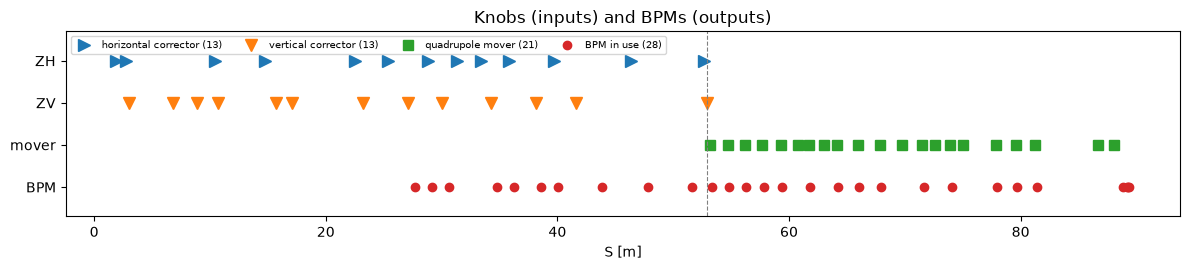

In [10]:
S_cx = [find(lat, c)[0].get_S() for c in CORRS_X]
S_cy = [find(lat, c)[0].get_S() for c in CORRS_Y]
S_m  = [find(lat, q)[0].get_S() for q in MOVERS]
S_b  = [find(lat, b)[0].get_S() for b in BPM_USE]

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.plot(S_cx, [3]*len(S_cx), '>', ms=8, label=f'horizontal corrector ({len(S_cx)})')
ax.plot(S_cy, [2]*len(S_cy), 'v', ms=8, label=f'vertical corrector ({len(S_cy)})')
ax.plot(S_m,  [1]*len(S_m),  's', ms=7, label=f'quadrupole mover ({len(S_m)})')
ax.plot(S_b,  [0]*len(S_b),  'o', ms=6, label=f'BPM in use ({len(S_b)})')
ax.axvline(S_last_corr, ls='--', c='gray', lw=0.8)
ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels(['BPM', 'mover', 'ZV', 'ZH'])
ax.set_ylim(-0.7, 3.7); ax.set_xlabel('S [m]')
ax.set_title('Knobs (inputs) and BPMs (outputs)')
ax.legend(loc='upper left', fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

# 3. 応答行列と補正の関数
- `response_matrix`, `measure_R`: clean 5 章と同じ。ノブを 1 つずつ少し動かして、読み値の変化を測る(R の各列)
- `apply_knobs`, `correct_orbit`, `beam_minus_quad_center`: clean 6 章と同じ。`correct_orbit(…, n_iter=1)` が補正 1 回
- `correct_until`(新規): 補正できるまでくり返し、各回の後の状態を記録する

In [11]:
def response_matrix(lat, bpms, corrs, movers, bunch, plane, d_corr=0.01, d_mov=0.01):
    """応答行列 R[i, k] = (ノブ k を +d 動かしたときの読み値 − 動かす前の読み値) / d
    ノブごとに「読む → 動かす → 読む → 元に戻す」。列の並び: [コレクタ..., ムーバー...]
    単位: コレクタの列 [mm/(T*mm)]、ムーバーの列 [mm/mm]"""
    j = 0 if plane == 'x' else 1
    R = np.zeros((len(bpms), len(corrs) + len(movers)))
    for k, c in enumerate(corrs):
        lat.track(bunch); r0 = read_bpms(lat, bpms)[1 + j]      # 動かす前
        s0 = get_corrector(lat, c)
        s1 = s0.copy(); s1[j] += d_corr
        set_corrector(lat, c, *s1); lat.track(bunch); r1 = read_bpms(lat, bpms)[1 + j]   # 動かした後
        set_corrector(lat, c, *s0)                                # 元に戻す
        R[:, k] = (r1 - r0) / d_corr
    for m, q in enumerate(movers):
        lat.track(bunch); r0 = read_bpms(lat, bpms)[1 + j]
        dd = np.zeros(2); dd[j] = d_mov
        move_girder(lat, q, *dd); lat.track(bunch); r1 = read_bpms(lat, bpms)[1 + j]
        move_girder(lat, q, *(-dd))
        R[:, len(corrs) + m] = (r1 - r0) / d_mov
    lat.track(bunch)
    return R

def measure_R(lat, bunch):
    """今のラティスの上で、水平と垂直の応答行列を測る"""
    return (response_matrix(lat, BPM_USE, CORRS_X, MOVERS, bunch, 'x'),
            response_matrix(lat, BPM_USE, CORRS_Y, MOVERS, bunch, 'y'))

nX, nY = len(CORRS_X), len(CORRS_Y)

In [12]:
def apply_knobs(lat, du, corrs, movers, plane):
    """ノブの変化量 du = [コレクタ... (T*mm), ムーバー... (mm)] を今の設定に足す"""
    j = 0 if plane == 'x' else 1
    for k, c in enumerate(corrs):
        s = get_corrector(lat, c); s[j] += du[k]
        set_corrector(lat, c, *s)
    for m, q in enumerate(movers):
        dd = np.zeros(2); dd[j] = du[len(corrs) + m]
        move_girder(lat, q, *dd)

def correct_orbit(lat, RX, RY, bunch, n_iter=3, rcond=1e-4):
    """読む → du = −R⁺ r → ノブに足す → track を n_iter 回。rcond: 補正できない方向を捨てる閾値(5.3 の段差で切れる値)"""
    RX_inv = np.linalg.pinv(RX, rcond=rcond)
    RY_inv = np.linalg.pinv(RY, rcond=rcond)
    lat.track(bunch)
    for it in range(n_iter):
        _, x, y = read_bpms(lat, BPM_USE)
        apply_knobs(lat, -RX_inv @ x, CORRS_X, MOVERS, 'x')
        apply_knobs(lat, -RY_inv @ y, CORRS_Y, MOVERS, 'y')
        lat.track(bunch)

QUADS_ON = [q for q in QUADS if sum(e.get_K1L(Pref) for e in find(lat, q)) != 0.0]   # 磁場のある四重極 42 台

def beam_minus_quad_center(lat):
    """各四重極の中心で (ビームの位置 − 磁場中心の位置) [mm]"""
    T = lat.get_transport_table('%S %mean_x %mean_y')
    dx, dy = [], []
    for q in QUADS_ON:
        Sc = find(lat, q)[0].get_S()                      # 1 枚目のスライスの出口 = 四重極の中心
        ox, oy = get_offset_mm(lat, q)                    # 磁場中心 = 四重極の今の位置
        dx.append(np.interp(Sc, T[:, 0], T[:, 1]) - ox)
        dy.append(np.interp(Sc, T[:, 0], T[:, 2]) - oy)
    return np.array(dx), np.array(dy)

KEYS = ['used BPM', 'unused BPM', 'true orbit', 'beam - quad']

def evaluate(lat):
    """4 指標の rms [mm] を {指標: (x, y)} で返す"""
    _, xu, yu = read_bpms(lat, BPM_USE)
    _, xn, yn = read_bpms(lat, BPM_UNUSED)
    _, xt, yt = true_orbit(lat)
    dx, dy = beam_minus_quad_center(lat)
    return dict(zip(KEYS, [(rms(xu), rms(yu)), (rms(xn), rms(yn)), (rms(xt), rms(yt)), (rms(dx), rms(dy))]))

def print_table(before, after):
    print(f'{"rms [um]":12s} {"x before":>9s} {"x after":>9s} {"y before":>9s} {"y after":>9s}')
    for k in KEYS:
        print(f'{k:12s} {before[k][0]*1e3:9.2f} {after[k][0]*1e3:9.2f} {before[k][1]*1e3:9.2f} {after[k][1]*1e3:9.2f}')

In [13]:
def converged(prev, cur):
    """補正できた: 粒子が終点まで届き、読み値の rms が x, y とも CONV_MM 未満で、前の回からの変化が CONV_REL 未満"""
    m0, m1 = max(prev['rms']), max(cur['rms'])
    return cur['alive'] == 1 and prev['alive'] == 1 and m1 < CONV_MM and abs(m1 - m0) < CONV_REL * m1   # alive = 届いた粒子の割合

BUNCHES = {'P1': P1, 'B0': B0}

def correct_until(seed, remeasure=REMEASURE_R, nmax=N_MAX, full=True, r_bunch=None, read_bunch=None):
    """誤差を入れた加速器(seed)で、その上で測った R を使って、補正できるまで(最大 nmax 回)くり返す。
    remeasure=True: 2 回目からは毎回 R を測り直す。
    戻り値 {'D': 据付誤差 {四重極: (dx, dy)} [mm], 'rec': 各回の後の記録のリスト(0 番目 = 補正前), 'ok': 補正できたか}
    R は r_bunch(既定 R_BUNCH)で測り、読み値・評価は read_bunch(既定 READ_BUNCH)で行う。
    記録 1 回分: alive(終点まで届いた粒子の割合。1 = 全部。get_ngood の確認は検証ノート A.12)、rms(読み値の rms (x, y) [mm])。full=True ならさらに
    read(BPM ごとの読み値 (x, y) [mm])、cx, cy(コレクタ [T*mm])、mv(ムーバーの移動量 = 今の位置 − Δ、(21, 2) [mm])、
    orbit(真の軌道 (S, x, y))、bq(ビーム − 磁場中心 (x, y) [mm]、QUADS_ON の順)"""
    r_b, rd_b = BUNCHES[r_bunch or R_BUNCH], BUNCHES[read_bunch or READ_BUNCH]
    l = load_lattice_default()                                   # ラティスは変数に入れておく(検証ノート A.1.4)
    D = apply_offsets(l, QUADS, ALL_BPMS, SIGMA_GIRDER_MM, SIGMA_BPM_MM, seed=seed)['girder']

    def snap():                                                  # 今の状態を track して記録する
        alive = l.track(rd_b).get_ngood() / rd_b.get_ngood()
        _, x, y = read_bpms(l, BPM_USE)
        h = {'alive': alive, 'rms': (rms(x), rms(y))}
        if full:
            h.update(read=(x, y),
                     cx=np.array([get_corrector(l, c)[0] for c in CORRS_X]),
                     cy=np.array([get_corrector(l, c)[1] for c in CORRS_Y]),
                     mv=np.array([get_offset_mm(l, q) - np.array(D[q]) for q in MOVERS]),
                     orbit=true_orbit(l), bq=beam_minus_quad_center(l))
        return h

    rec = [snap()]
    Rx, Ry = measure_R(l, r_b)                                   # この seed の加速器で R を測る
    for k in range(1, nmax + 1):
        if remeasure and k > 1:
            Rx, Ry = measure_R(l, r_b)                           # 今の加速器で測り直す
        correct_orbit(l, Rx, Ry, rd_b, n_iter=1)                 # 補正 1 回(読み値は rd_b で読む)
        rec.append(snap())
        if converged(rec[-2], rec[-1]):
            break
    return {'D': D, 'rec': rec, 'ok': converged(rec[-2], rec[-1])}

S_USED = np.array([find(lat, b)[0].get_S() for b in BPM_USE])  # 使う BPM の位置 [m]
S_FIRST = S_USED.min()                                          # 最初の使う BPM [m]
S_Q = np.array([find(lat, q)[0].get_S() for q in QUADS_ON])    # 磁場のある四重極の位置 [m]
print(f'first used BPM at S = {S_FIRST:.2f} m;  knobs per plane {nX} + {len(MOVERS)};  quadrupoles with field {len(QUADS_ON)}')

first used BPM at S = 27.75 m;  knobs per plane 13 + 21;  quadrupoles with field 42


# 4. seed 1 本で補正する
`SEED_ONE` の加速器で、補正できるまでくり返す。各回の後の BPM ごとの読み値、ノブの変化、真の軌道を見る。

In [14]:
t0 = time.time()
one = correct_until(SEED_ONE)
n1 = len(one['rec']) - 1
print(f'seed {SEED_ONE} (σ = {SIGMA_GIRDER_MM*1e3:g} um, R {"re-measured every step" if REMEASURE_R else "fixed"}, R with {R_BUNCH}, readings with {READ_BUNCH}): '
      f'{"corrected" if one["ok"] else "NOT corrected"} after {n1} steps  ({time.time() - t0:.0f} s)\n')
print(f'{"step":>4s} {"alive":>6s} | {"readings rms [um]":^18s} | {"readings max|.| [um]":^20s} | {"true orbit rms [um]":^18s} | {"knob change max|.|":^24s}')
print(f'{"":11s} | {"x":>9s}{"y":>9s} | {"x":>10s}{"y":>10s} | {"x":>9s}{"y":>9s} | {"BL [T mm]":>10s}{"mover [um]":>14s}')
for k, h in enumerate(one['rec']):
    (x, y), (S, ox, oy) = h['read'], h['orbit']
    if k:
        p = one['rec'][k - 1]
        dk = f'{max(np.abs(h["cx"] - p["cx"]).max(), np.abs(h["cy"] - p["cy"]).max()):10.3g}{np.abs(h["mv"] - p["mv"]).max() * 1e3:14.3g}'
    else:
        dk = f'{"-":>10s}{"-":>14s}'
    print(f'{k:4d} {h["alive"]:6.2f} | {rms(x)*1e3:9.3g}{rms(y)*1e3:9.3g} | {np.abs(x).max()*1e3:10.3g}{np.abs(y).max()*1e3:10.3g} | '
          f'{rms(ox)*1e3:9.3g}{rms(oy)*1e3:9.3g} | {dk}')

seed 1 (σ = 100 um, R re-measured every step, R with P1, readings with B0): corrected after 4 steps  (18 s)

step  alive | readings rms [um]  | readings max|.| [um] | true orbit rms [um] |    knob change max|.|   
            |         x        y |          x         y |         x        y |  BL [T mm]    mover [um]
   0   1.00 |     2e+03 7.43e+03 |   7.11e+03  2.06e+04 |  1.88e+03 9.07e+03 |          -             -
   1   1.00 |  1.97e+03      130 |   7.57e+03       290 |  1.85e+03      398 |      0.839      3.72e+03
   2   1.00 |      41.3     26.6 |        164      92.7 |       276      381 |     0.0392       3.7e+03
   3   1.00 |      5.58     25.8 |       19.4      92.7 |       277      381 |   0.000248            50
   4   1.00 |      5.58     25.8 |       19.4      92.7 |       277      381 |   2.27e-06        0.0853


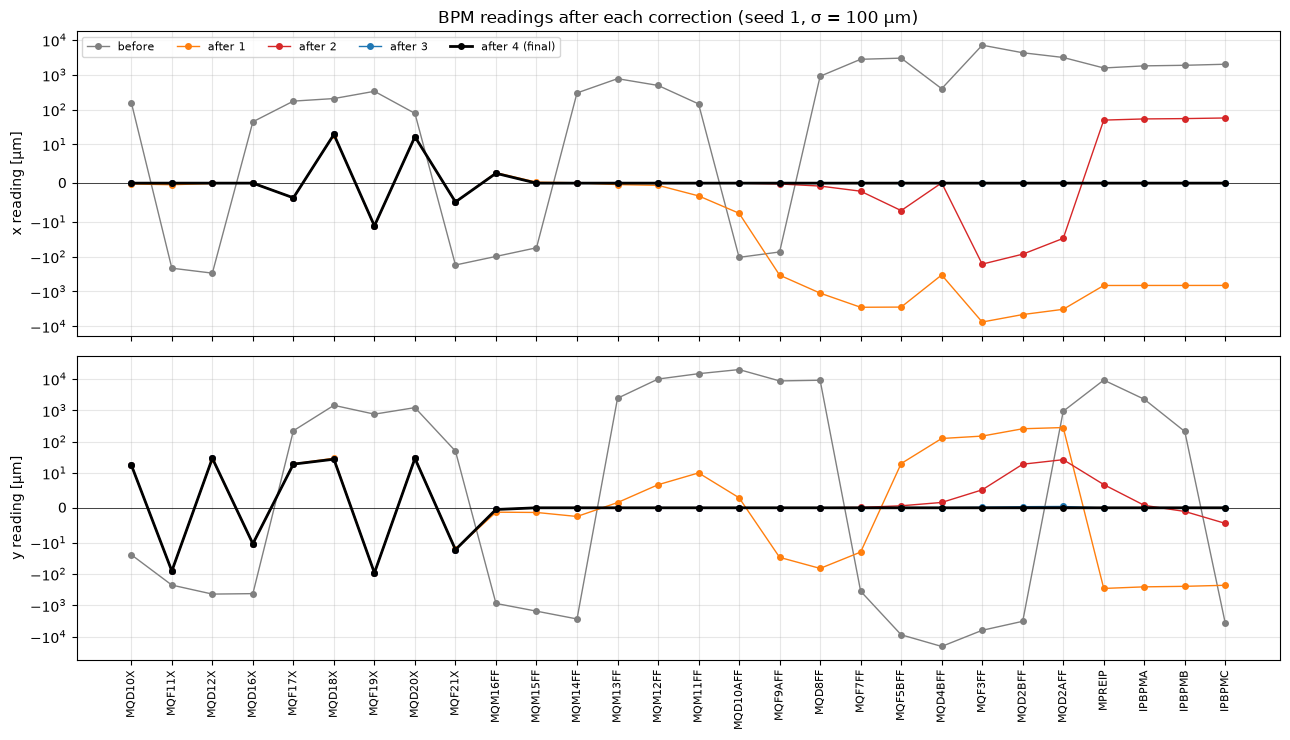

In [15]:
# BPM ごとの読み値(各回の後)。縦軸は符号つきの対数(±10 µm の内側は線形)。白抜き = 粒子の一部または全部が終点まで届いていない
show_k = sorted(set([0, 1, 2, 3, n1]) & set(range(n1 + 1)))
cols = {0: 'gray', 1: 'C1', 2: 'C3', 3: 'C0'}
fig, axs = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
for ax, j, p in [(axs[0], 0, 'x'), (axs[1], 1, 'y')]:
    for k in show_k:
        h = one['rec'][k]; col = 'k' if k == n1 else cols[k]
        ax.plot(range(len(BPM_USE)), h['read'][j] * 1e3, 'o-' if h['alive'] == 1 else 'o--', ms=4, lw=2 if k == n1 else 1, color=col,
                mfc=col if h['alive'] == 1 else 'none', label='before' if k == 0 else f'after {k}' + (' (final)' if k == n1 else ''))
    ax.set_yscale('symlog', linthresh=10); ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3, which='both')
    ax.set_ylabel(f'{p} reading [µm]')
axs[0].legend(fontsize=8, ncol=5, loc='upper left')
axs[0].set_title(f'BPM readings after each correction (seed {SEED_ONE}, σ = {SIGMA_GIRDER_MM*1e3:g} µm)')
axs[1].set_xticks(range(len(BPM_USE))); axs[1].set_xticklabels(BPM_USE, rotation=90, fontsize=8)
fig.tight_layout(); plt.show()

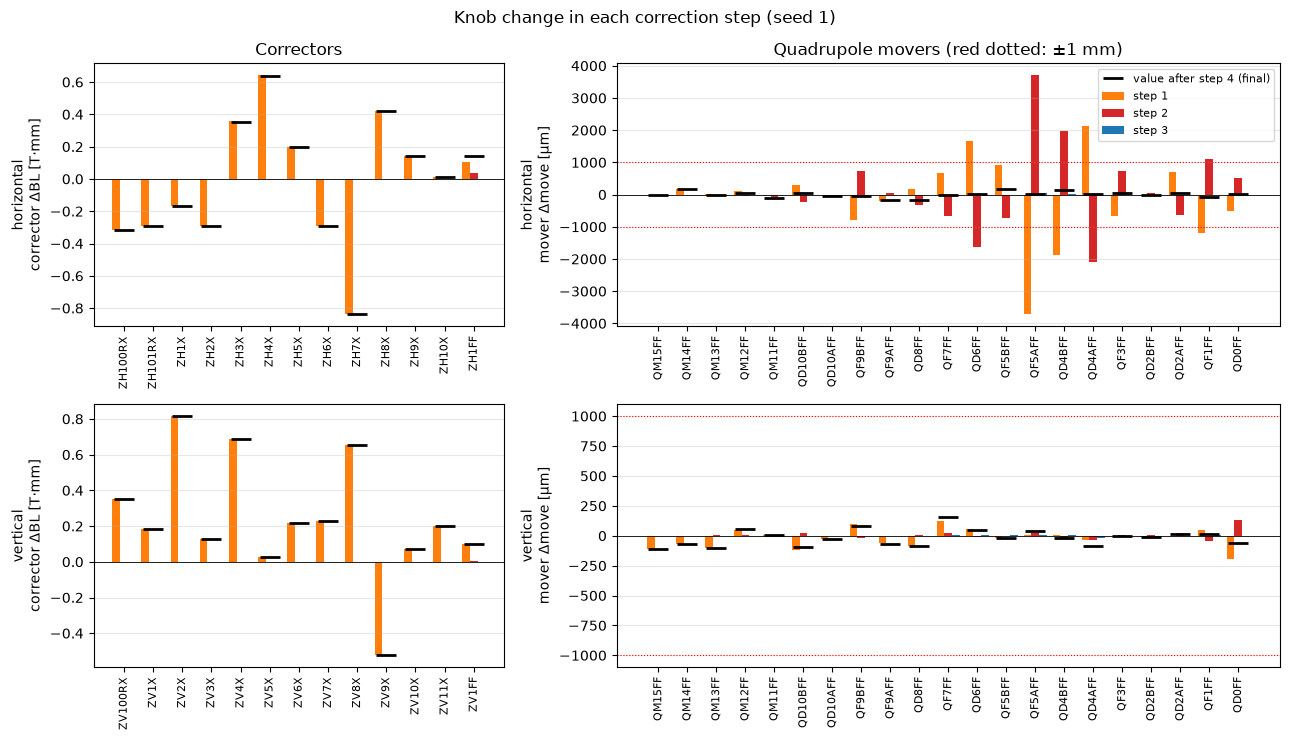

In [16]:
# 各回のノブの変化(その回の後 − その回の前)。黒の横棒 = 最後の値
knob_of = lambda h: (h['cx'], h['mv'][:, 0] * 1e3, h['cy'], h['mv'][:, 1] * 1e3)
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5), gridspec_kw={'width_ratios': [13, 21]})
for (r, c), j, names, ylab in [((0, 0), 0, CORRS_X, 'horizontal\ncorrector ΔBL [T·mm]'), ((0, 1), 1, MOVERS, 'horizontal\nmover Δmove [µm]'),
                               ((1, 0), 2, CORRS_Y, 'vertical\ncorrector ΔBL [T·mm]'),   ((1, 1), 3, MOVERS, 'vertical\nmover Δmove [µm]')]:
    ax, pos = axs[r, c], np.arange(len(names)); ks = [k for k in (1, 2, 3) if k <= n1]; w = 0.8 / len(ks)
    for i, k in enumerate(ks):
        ax.bar(pos + (i - (len(ks) - 1) / 2) * w, knob_of(one['rec'][k])[j] - knob_of(one['rec'][k - 1])[j], w, color=cols[k], label=f'step {k}')
    ax.plot(pos, knob_of(one['rec'][-1])[j], '_', color='k', ms=14, mew=2, label=f'value after step {n1} (final)')
    if 'mover' in ylab:
        ax.axhline(MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8); ax.axhline(-MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8)
    ax.axhline(0, color='k', lw=0.6); ax.grid(alpha=0.3, axis='y'); ax.set_ylabel(ylab)
    ax.set_xticks(pos); ax.set_xticklabels(names, rotation=90, fontsize=8)
axs[0, 0].set_title('Correctors'); axs[0, 1].set_title(f'Quadrupole movers (red dotted: ±{MOVER_LIMIT_MM:g} mm)'); axs[0, 1].legend(fontsize=8)
fig.suptitle(f'Knob change in each correction step (seed {SEED_ONE})')
fig.tight_layout(); plt.show()

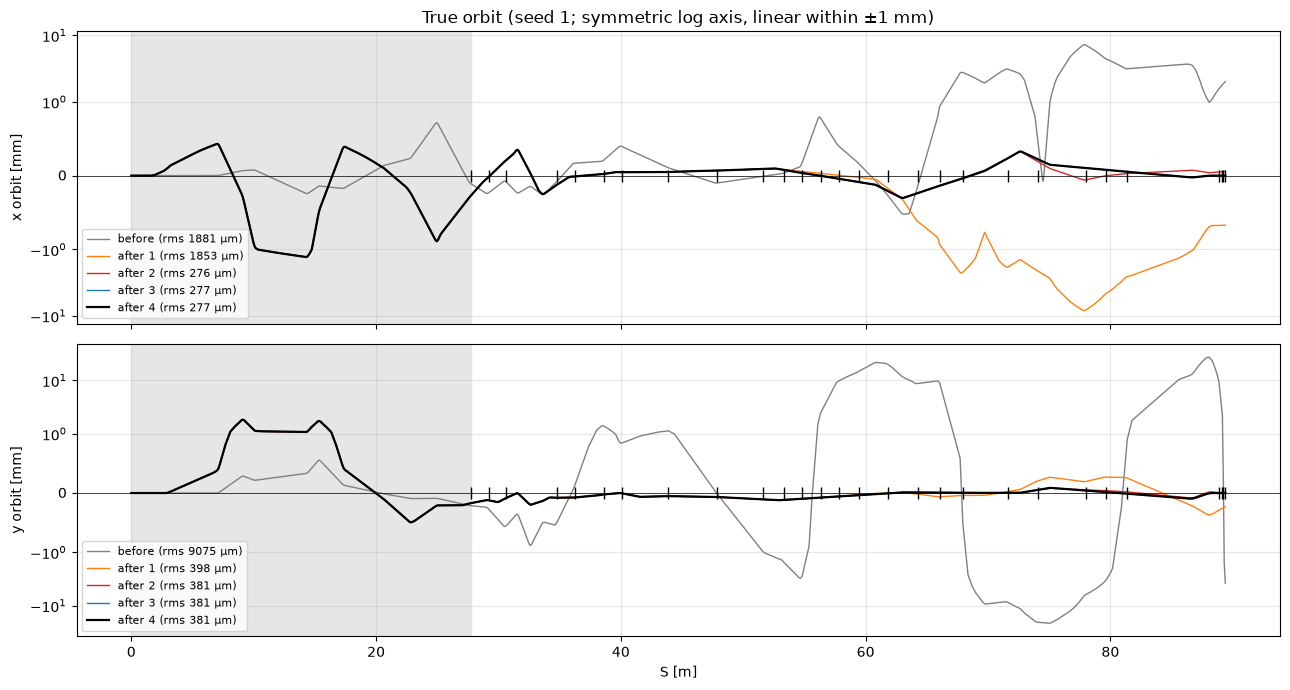

In [17]:
# 真の軌道(設計軸から)。灰色の帯 = 使う BPM が無い区間(最初の BPM より上流)、目盛り = 使う BPM
fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, j, p in [(axs[0], 1, 'x'), (axs[1], 2, 'y')]:
    for k in show_k:
        o = one['rec'][k]['orbit']
        ax.plot(o[0], o[j], color='k' if k == n1 else cols[k], lw=1.6 if k == n1 else 1,
                label=('before' if k == 0 else f'after {k}') + f' (rms {rms(o[j])*1e3:.0f} µm)')
    ax.axvspan(0, S_FIRST, color='0.9', zorder=0); ax.plot(S_USED, np.zeros(len(S_USED)), '|', color='k', ms=8)
    ax.set_yscale('symlog', linthresh=1); ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3); ax.set_ylabel(f'{p} orbit [mm]')
    ax.legend(fontsize=8, loc='lower left')
axs[0].set_title(f'True orbit (seed {SEED_ONE}; symmetric log axis, linear within ±1 mm)'); axs[1].set_xlabel('S [m]')
fig.tight_layout(); plt.show()

# 5. 複数 seed で補正する
`SEEDS` のそれぞれで、4 章と同じことをする(seed を変えると加速器の配置が変わるので、R も seed ごとに測る)。
補正できなかった seed(上限まで来た seed)は一覧の図と表だけに出し、6 章の図は補正できた seed で描く。
一覧の図(下)の印: ○ = 補正前、□ = 最後。塗りつぶし = `READ_BUNCH`(B0)の全粒子が終点まで届いた、白抜き = 一部または全部が失われた(読み値に意味がない)、× = 1 個も届かず読み値が 0。

In [18]:
t0 = time.time()
runs = {s: correct_until(s) for s in SEEDS}
print(f'{len(SEEDS)} seeds in {time.time() - t0:.0f} s')
if COMPARE_FIXED_R:
    t0 = time.time()
    runs_ref = {s: correct_until(s, remeasure=not REMEASURE_R, full=False) for s in SEEDS}   # 参考: もう一方の R の扱い
    print(f'reference ({"fixed R" if REMEASURE_R else "R re-measured"}): {time.time() - t0:.0f} s')

mx = lambda h: max(h['rms']) * 1e3                                                   # max(rms x, rms y) [µm]
OK_SEEDS = [s for s in SEEDS if runs[s]['ok']]
LOST0 = {s: runs[s]['rec'][0]['alive'] < 1 for s in SEEDS}                           # 補正前に粒子が(一部でも)失われていた
print(f'\n{"seed":>4s} | {"before":^18s} | {"main setting":^30s} |' + (f' {"reference":^22s}' if COMPARE_FIXED_R else ''))
print(f'{"":4s} | {"max rms [um]":>12s}{"alive":>6s} | {"steps":>6s}{"final [um]":>12s}{"alive":>6s}{"ok":>5s} |'
      + (f' {"steps":>6s}{"final [um]":>11s}{"ok":>5s}' if COMPARE_FIXED_R else ''))
for s in SEEDS:
    r = runs[s]; h0, h1 = r['rec'][0], r['rec'][-1]
    line = f'{s:4d} | {mx(h0):12.3g}{h0["alive"]:6.2f} | {len(r["rec"]) - 1:6d}{mx(h1):12.3g}{h1["alive"]:6.2f}{"yes" if r["ok"] else "-":>5s} |'
    if COMPARE_FIXED_R:
        f = runs_ref[s]; line += f' {len(f["rec"]) - 1:6d}{mx(f["rec"][-1]):11.3g}{"yes" if f["ok"] else "-":>5s}'
    print(line)
print(f'\ncorrected: {len(OK_SEEDS)}/{len(SEEDS)} {OK_SEEDS}' + (f';  reference: {sum(runs_ref[s]["ok"] for s in SEEDS)}/{len(SEEDS)}' if COMPARE_FIXED_R else ''))
print(f'particle lost before correction: {[s for s in SEEDS if LOST0[s]]}')

20 seeds in 2029 s

seed |       before       |          main setting          |
     | max rms [um] alive |  steps  final [um] alive   ok |
   1 |     7.43e+03  1.00 |      4        25.8  1.00  yes |
   2 |     3.31e+06  0.47 |      8        43.1  1.00  yes |
   3 |     7.93e+08  0.00 |      6        29.5  1.00  yes |
   4 |     1.36e+08  0.00 |    100    8.08e+07  0.00    - |
   5 |     1.99e+06  0.06 |      7        19.5  1.00  yes |
   6 |     8.48e+06  0.00 |     60        35.3  1.00  yes |
   7 |     1.25e+07  0.00 |    100    3.24e+06  0.00    - |
   8 |     4.94e+06  0.00 |      7          33  1.00  yes |
   9 |     7.43e+03  1.00 |      4        39.7  1.00  yes |
  10 |     6.98e+03  1.00 |      4        37.7  1.00  yes |
  11 |     3.47e+03  1.00 |      3        31.2  1.00  yes |
  12 |     1.89e+07  0.00 |     14        25.6  1.00  yes |
  13 |     2.76e+03  1.00 |      3          23  1.00  yes |
  14 |     4.82e+06  0.00 |      6        34.5  1.00  yes |
  15 |     4.08e+06

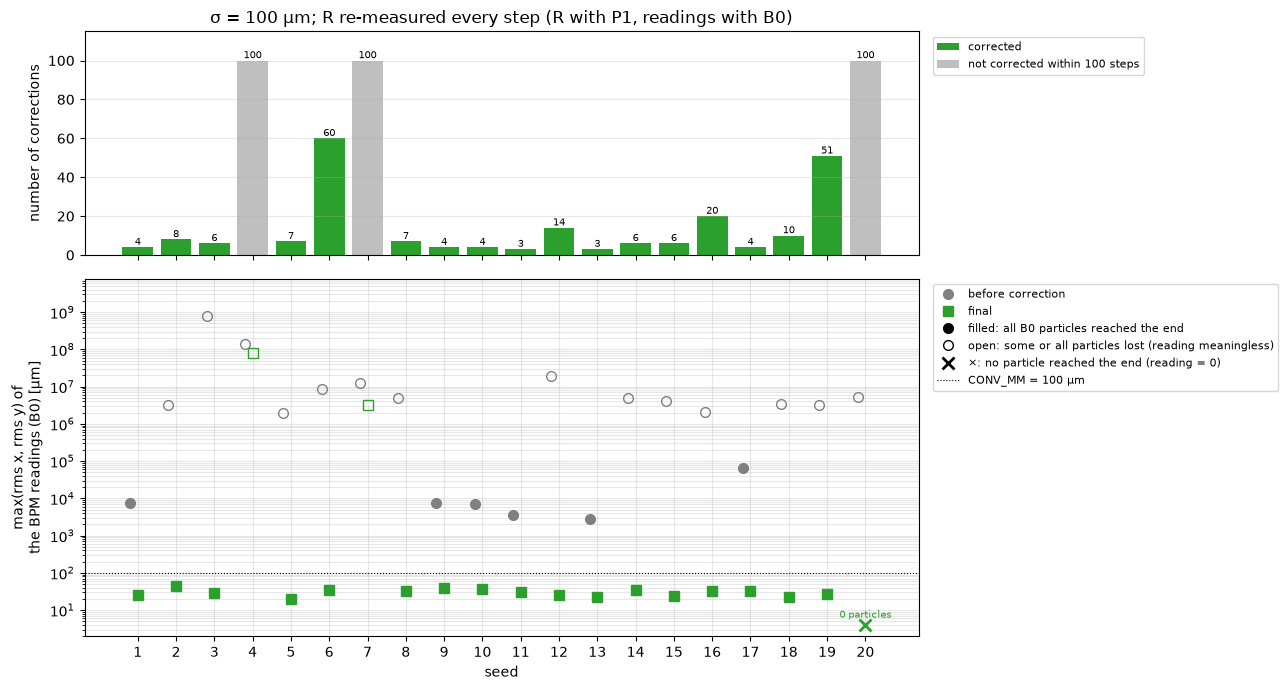

In [19]:
# seed ごとの一覧。上: 補正の回数(緑 = 補正できた、灰色 = 上限まで来た)
# 下: 読み値の大きさ。印の形 = いつの値か(○ 補正前、□ 最後)、塗りつぶし = READ_BUNCH の全粒子が終点まで届いた、
#     白抜き = 一部または全部が失われた(読み値に意味がない)、× = 1 個も届かず読み値が 0(対数の軸に描けないので下端に置く)
sx = np.array(SEEDS); ok = np.array([runs[s]['ok'] for s in SEEDS]); nit = np.array([len(runs[s]['rec']) - 1 for s in SEEDS])
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [1, 1.6]})
ax_a.bar(sx[ok], nit[ok], color='C2', label='corrected'); ax_a.bar(sx[~ok], nit[~ok], color='0.75', label=f'not corrected within {N_MAX} steps')
for s, n in zip(sx, nit):
    ax_a.text(s, n, str(n), ha='center', va='bottom', fontsize=7)
ax_a.set_ylabel('number of corrections'); ax_a.set_ylim(0, N_MAX * 1.15); ax_a.grid(alpha=0.3, axis='y')
ax_a.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
ax_a.set_title(f'σ = {SIGMA_GIRDER_MM*1e3:g} µm; R {"re-measured every step" if REMEASURE_R else "fixed"} (R with {R_BUNCH}, readings with {READ_BUNCH})')
sets = [([runs[s] for s in SEEDS], -0.2, 'gray', 'o', 'before correction', 0), ([runs[s] for s in SEEDS], 0.0, 'C2', 's', 'final', -1)]
if COMPARE_FIXED_R:
    sets.append(([runs_ref[s] for s in SEEDS], 0.2, 'C3', 'D', f'final (reference: R {"fixed" if REMEASURE_R else "re-measured"})', -1))
v_all = np.concatenate([[mx(r['rec'][k]) for r in recs] for recs, *_, k in sets]); v_pos = v_all[v_all > 0]
y_floor = v_pos.min() / 5                                                          # 読み値が 0 の点を置く高さ
for recs, dx, col, mk, lab, k in sets:
    v = np.array([mx(r['rec'][k]) for r in recs]); frac = np.array([r['rec'][k]['alive'] for r in recs])
    full, part, none = frac == 1, (frac < 1) & (v > 0), v == 0
    ax_b.semilogy(sx[full] + dx, v[full], mk, color=col, ms=7)
    ax_b.semilogy(sx[part] + dx, v[part], mk, color=col, mfc='none', ms=7)
    ax_b.semilogy(sx[none] + dx, np.full(none.sum(), y_floor), 'x', color=col, ms=8, mew=2)
    for s in sx[none]:
        ax_b.text(s + dx, y_floor * 1.6, '0 particles', fontsize=7, ha='center', color=col)
    ax_b.plot([], [], mk, color=col, ms=7, label=lab)
ax_b.plot([], [], 'o', color='k', ms=7, label=f'filled: all {READ_BUNCH} particles reached the end')
ax_b.plot([], [], 'o', color='k', mfc='none', ms=7, label='open: some or all particles lost (reading meaningless)')
ax_b.plot([], [], 'x', color='k', ms=8, mew=2, label='×: no particle reached the end (reading = 0)')
ax_b.axhline(CONV_MM * 1e3, color='k', lw=0.8, ls=':', label=f'CONV_MM = {CONV_MM*1e3:g} µm')
ax_b.set_ylim(y_floor / 2, v_pos.max() * 10)
ax_b.set_ylabel(f'max(rms x, rms y) of\nthe BPM readings ({READ_BUNCH}) [µm]'); ax_b.set_xlabel('seed'); ax_b.set_xticks(sx)
ax_b.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1)); ax_b.grid(alpha=0.3, which='both')
fig.tight_layout(); plt.show()

# 6. 補正できた seed のまとめ
6 章の図の色: **青・緑** = 補正前から B0 の全粒子が終点まで届いていた seed、**橙** = 補正前は粒子の一部または全部が失われていて、くり返しの途中で全粒子が届くようになった seed(粒子が失われている間は、読み値も R も意味のない値で、補正は手探りになる)。図によっては、橙の seed を破線や「(lost before)」の表示で区別している。5 章の一覧の図は色ではなく、塗りつぶし / 白抜きで区別している。

## 6.1 BPM ごとの読み値
rms は 1 つの値にまとめるので、1 台だけ外れていても目立たない。BPM ごとに、読み値が 0 になっているかを見る。
上: seed ごとの推移(縦軸は符号つきの対数なので、±10 µm を超える値は大きく見える)。下: 最後の読み値の表(色と数字)。EXT の BPM に読み値が残る理由は、検証ノート A.8(EXT の BPM の上流にコレクタが偏っていて、作れない方向がある)。

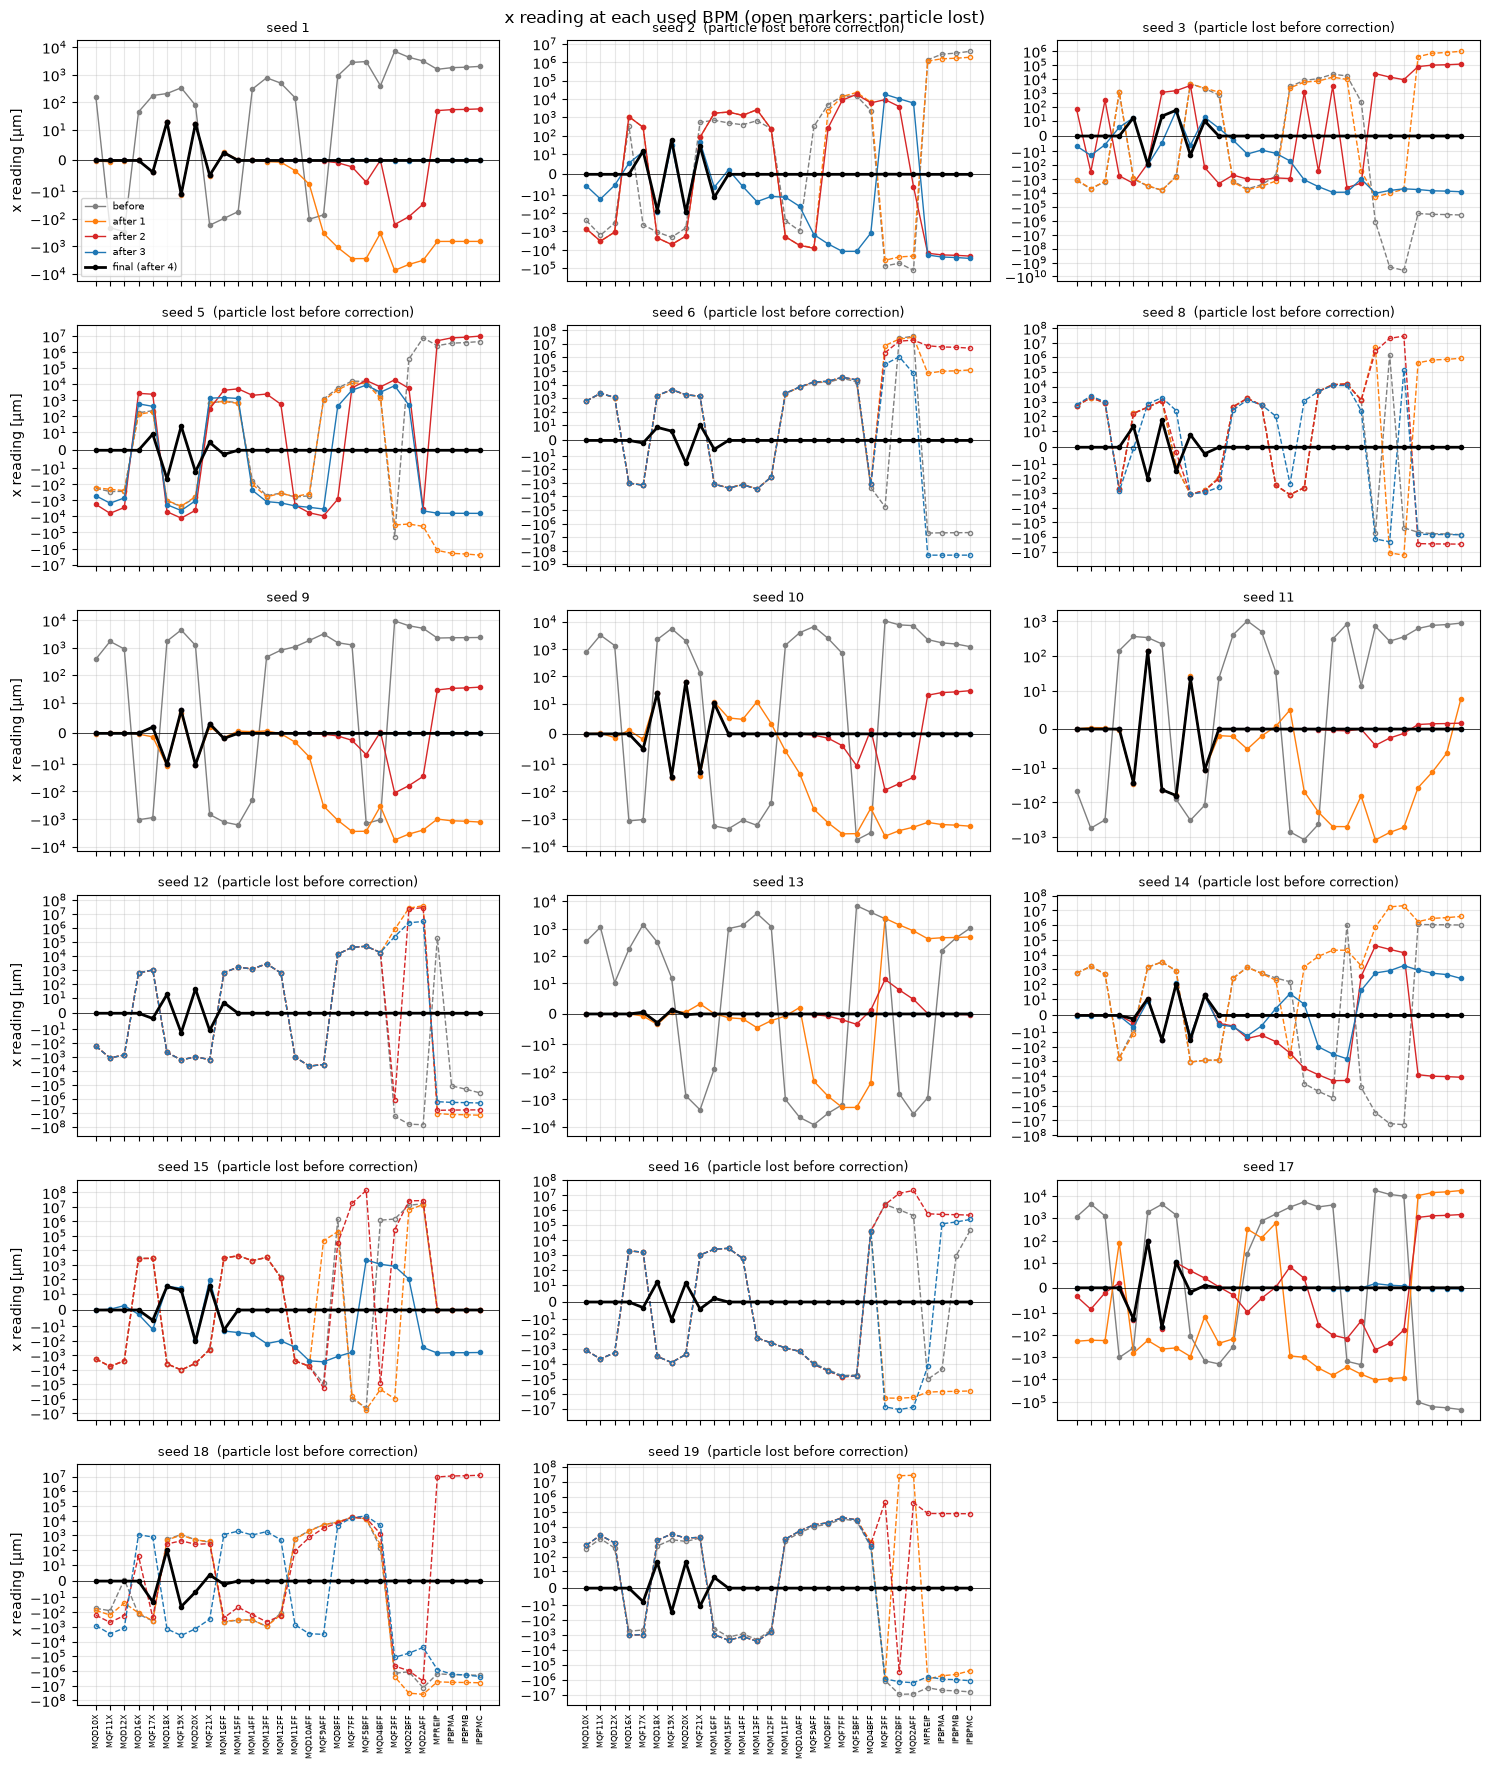

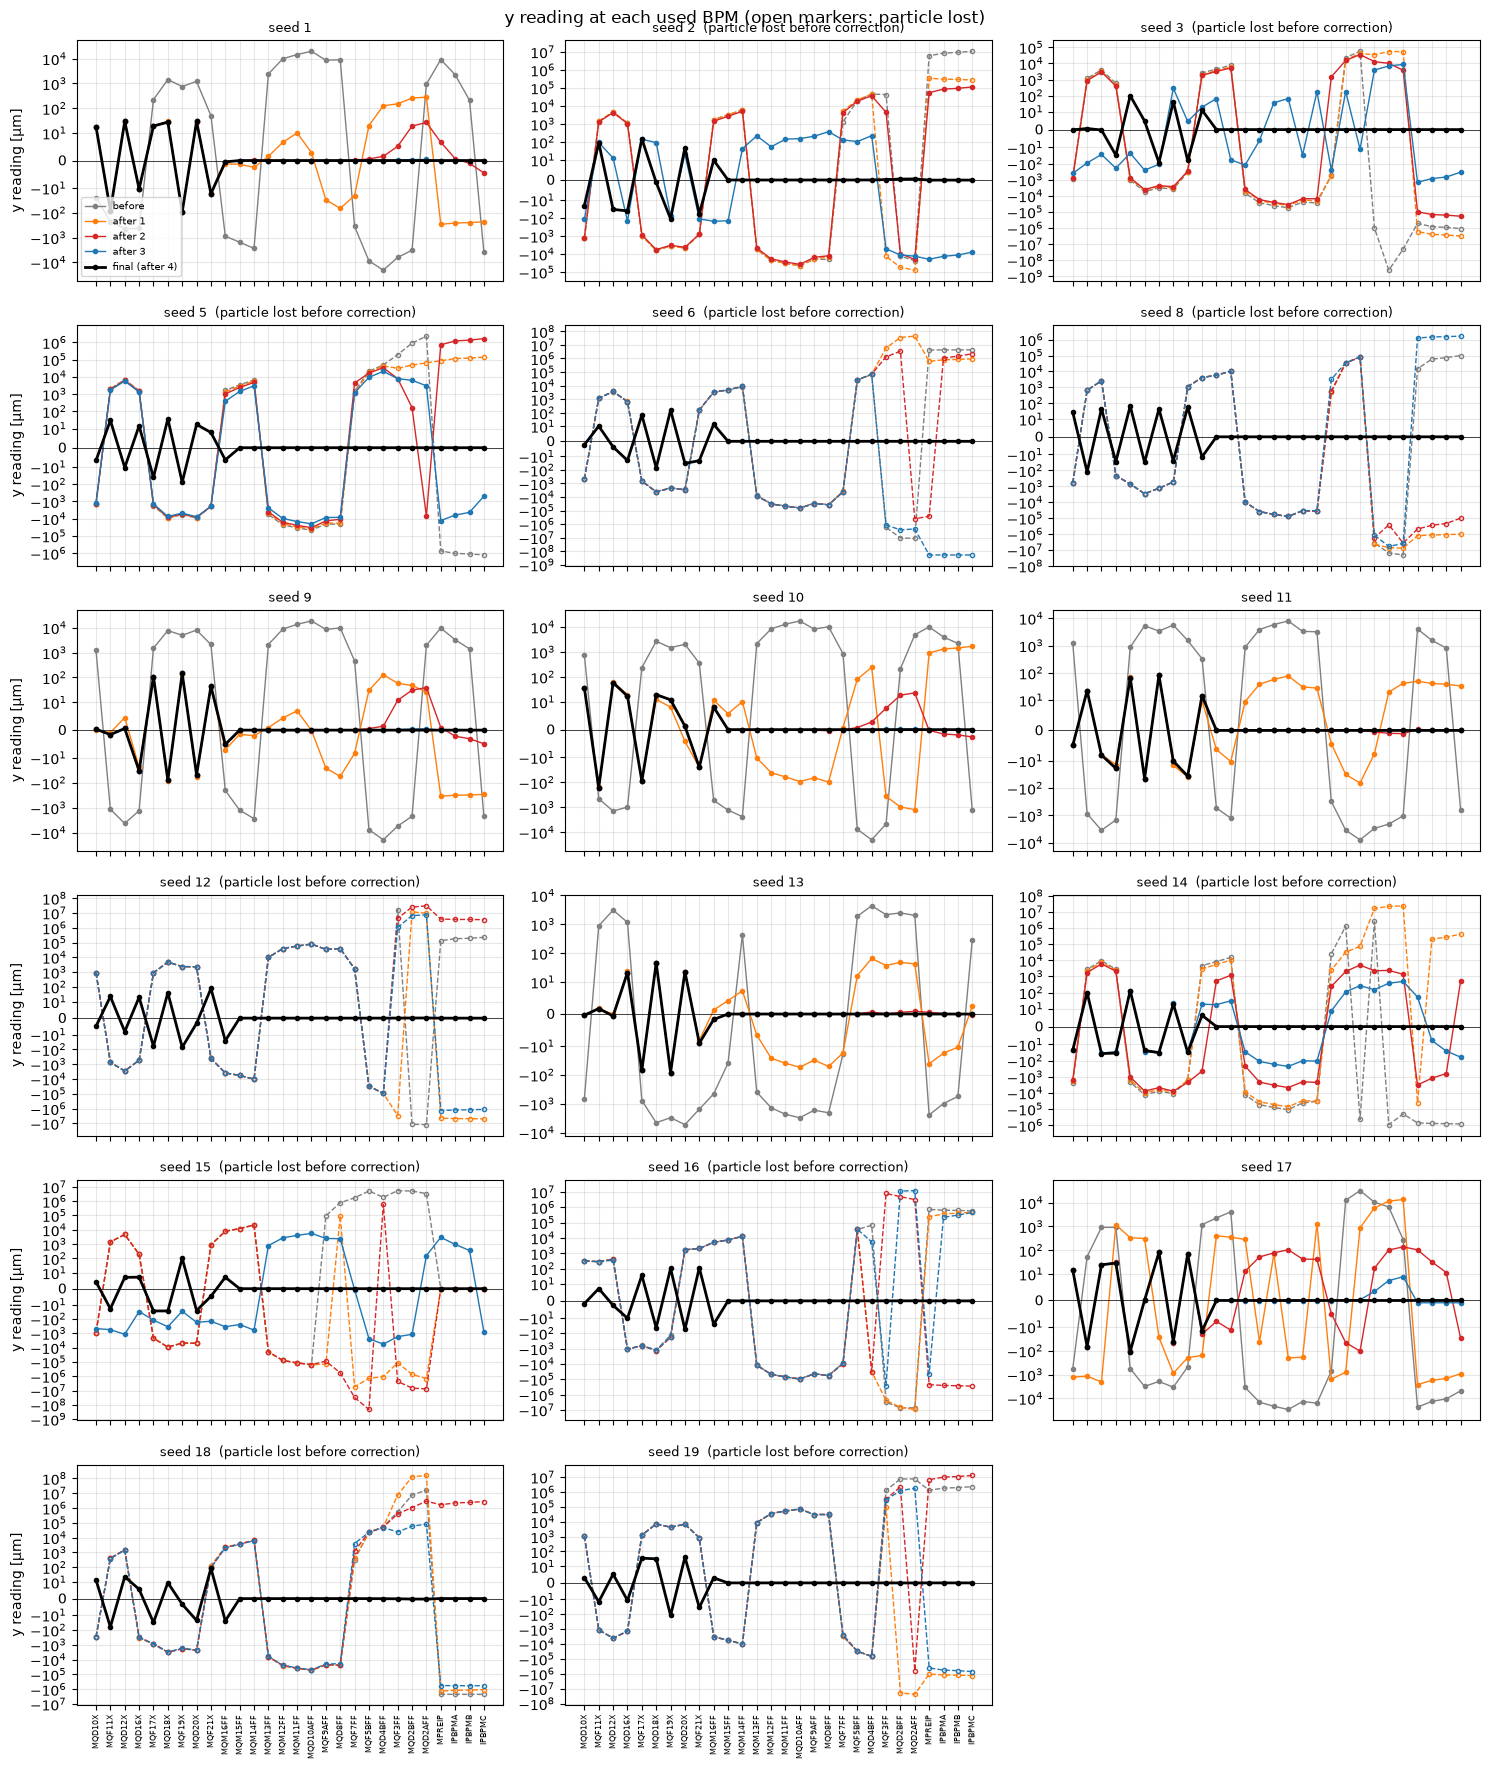

In [20]:
ok_runs = [runs[s] for s in OK_SEEDS]
lost0 = np.array([LOST0[s] for s in OK_SEEDS])
bi = np.arange(len(BPM_USE))
seed_col = lambda s: plt.cm.tab20(SEEDS.index(s) % 20 / 20)

# seed ごとの推移(x と y で 1 枚ずつ)。縦軸は符号つきの対数(±10 µm の内側は線形)
nc = 3; nr = int(np.ceil(len(OK_SEEDS) / nc))
for j, p in [(0, 'x'), (1, 'y')]:
    fig, axs = plt.subplots(nr, nc, figsize=(15, 3 * nr), sharex=True, squeeze=False)
    for ax, r, s in zip(axs.ravel(), ok_runs, OK_SEEDS):
        n = len(r['rec']) - 1
        for k, col, lw, lab in [(0, 'gray', 1.0, 'before'), (1, 'C1', 1.0, 'after 1'), (2, 'C3', 1.0, 'after 2'), (3, 'C0', 1.0, 'after 3'), (n, 'k', 2.0, f'final (after {n})')]:
            if k > n: continue
            h = r['rec'][k]
            ax.plot(bi, h['read'][j] * 1e3, 'o-' if h['alive'] == 1 else 'o--', ms=3, lw=lw, color=col, mfc=col if h['alive'] == 1 else 'none', label=lab)
        ax.set_yscale('symlog', linthresh=10); ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3, which='both')
        ax.set_title(f'seed {s}' + ('  (particle lost before correction)' if LOST0[s] else ''), fontsize=9)
    for ax in axs.ravel()[len(OK_SEEDS):]:
        ax.axis('off')
    for ax in axs[:, 0]:
        ax.set_ylabel(f'{p} reading [µm]')
    for ax in axs[-1]:
        ax.set_xticks(bi); ax.set_xticklabels(BPM_USE, rotation=90, fontsize=6); ax.tick_params(labelbottom=True)
    axs[0, 0].legend(fontsize=7, loc='lower left')
    fig.suptitle(f'{p} reading at each used BPM (open markers: particle lost)'); fig.tight_layout(); plt.show()

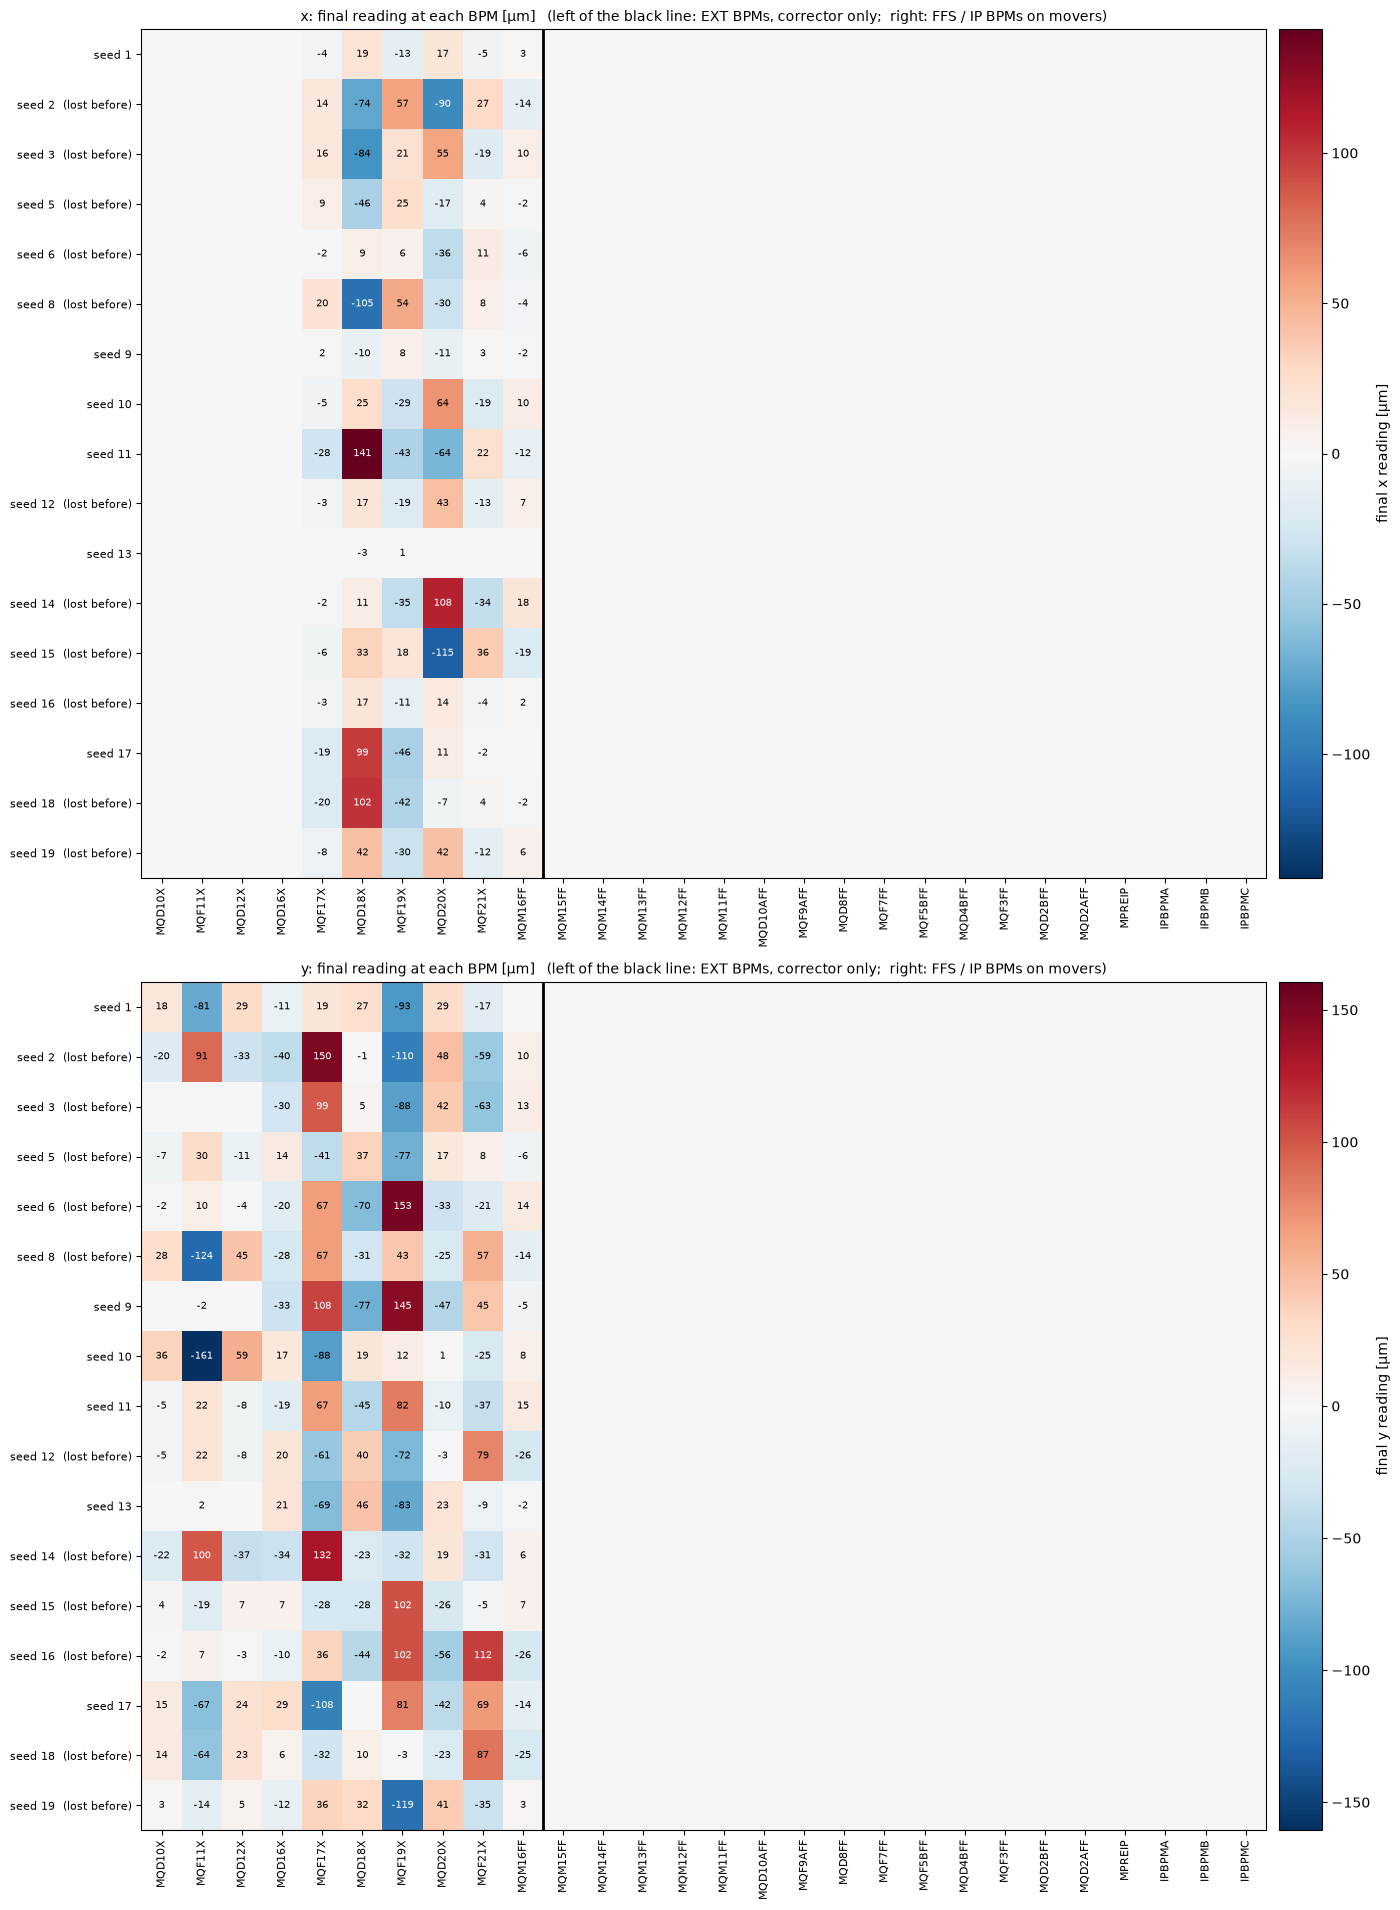

seed |  x: rms  max|.| at         |  y: rms  max|.| at         | BPMs with |reading| > 50 um   [um]
   1 |     5.6    19.4 MQD18X     |    25.8    92.7 MQF19X     | MQF11X y-81, MQF19X y-93
   2 |    25.3    90.1 MQD20X     |    43.1   150.3 MQF17X     | MQD18X x-74, MQF19X x+57, MQD20X x-90, MQF11X y+91, MQF17X y+150, MQF19X y-110, MQF21X y-59
   3 |    20.1    84.2 MQD18X     |    29.5    98.9 MQF17X     | MQD18X x-84, MQD20X x+55, MQF17X y+99, MQF19X y-88, MQF21X y-63
   5 |    10.6    46.2 MQD18X     |    19.5    77.2 MQF19X     | MQF19X y-77
   6 |     7.4    35.5 MQD20X     |    35.3   152.5 MQF19X     | MQF17X y+67, MQD18X y-70, MQF19X y+153
   8 |    23.4   104.8 MQD18X     |    33.0   124.2 MQF11X     | MQD18X x-105, MQF19X x+54, MQF11X y-124, MQF17X y+67, MQF21X y+57
   9 |     3.3    10.7 MQD20X     |    39.7   144.8 MQF19X     | MQF17X y+108, MQD18X y-77, MQF19X y+145
  10 |    14.7    63.9 MQD20X     |    37.7   160.6 MQF11X     | MQD20X x+64, MQF11X y-161, MQD12X y+59, MQ

In [21]:
# 最後の読み値: seed(行)× BPM(列)。赤 = 正、青 = 負、白 = 0。数字 = 読み値 [µm](|読み値| ≥ 1 µm のとき)
# 黒の縦線より左 = EXT の BPM(コレクタでしか動かせない)、右 = FFS と IP の BPM(四重極と同じ架台に載り、ムーバーで動かせる)
NE = BPM_USE.index('MQM15FF')
fig, axs = plt.subplots(2, 1, figsize=(15, 2.2 + 0.5 * len(ok_runs) * 2))
for ax, j, p in [(axs[0], 0, 'x'), (axs[1], 1, 'y')]:
    F = np.array([r['rec'][-1]['read'][j] for r in ok_runs]) * 1e3                  # (seed, BPM) [µm]
    vmax = max(np.abs(F).max(), 1.0)
    im = ax.imshow(F, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    for i in range(F.shape[0]):
        for b in range(F.shape[1]):
            if abs(F[i, b]) >= 1:
                ax.text(b, i, f'{F[i, b]:.0f}', ha='center', va='center', fontsize=7, color='w' if abs(F[i, b]) > 0.6 * vmax else 'k')
    ax.axvline(NE - 0.5, color='k', lw=2)
    ax.set_yticks(range(len(OK_SEEDS))); ax.set_yticklabels([f'seed {s}' + ('  (lost before)' if LOST0[s] else '') for s in OK_SEEDS], fontsize=8)
    ax.set_xticks(bi); ax.set_xticklabels(BPM_USE, rotation=90, fontsize=8)
    ax.set_title(f'{p}: final reading at each BPM [µm]   (left of the black line: EXT BPMs, corrector only;  right: FFS / IP BPMs on movers)', fontsize=10)
    fig.colorbar(im, ax=ax, label=f'final {p} reading [µm]', pad=0.01)
fig.tight_layout(); plt.show()

print(f'{"seed":>4s} | {"x: rms":>7s} {"max|.|":>7s} {"at":10s} | {"y: rms":>7s} {"max|.|":>7s} {"at":10s} | BPMs with |reading| > 50 um   [um]')
for r, s in zip(ok_runs, OK_SEEDS):
    x, y = (v * 1e3 for v in r['rec'][-1]['read'])
    big = [f'{b} {p}{v:+.0f}' for p, vv in [('x', x), ('y', y)] for b, v in zip(BPM_USE, vv) if abs(v) > 50]
    print(f'{s:4d} | {rms(x):7.1f} {np.abs(x).max():7.1f} {BPM_USE[np.abs(x).argmax()]:10s} | {rms(y):7.1f} {np.abs(y).max():7.1f} {BPM_USE[np.abs(y).argmax()]:10s} | '
          + (', '.join(big) if big else '-'))

## 6.2 軌道の補正の推移
横軸は補正の回数(対数。補正前の値は左端の印)。上から、読み値の最大値 max|·|(実線)と rms(点線)、真の軌道の rms(最初の使う BPM より下流)、ビーム − 四重極の磁場中心の rms(本当の目的)を、**自分の BPM を補正に使っている四重極(23 台。BPM の電気的中心 = 磁場中心なので、上段の読み値と比べられる)**と、**使っていない四重極(19 台。見ていない場所)**に分けて。自分の BPM を使っている四重極でも、BPM は四重極の中心より約 0.12 m 下流にあるので、ビームに角度があると読み値とビーム − 磁場中心は少しずれる(検証ノート A.10)。破線 = 補正前は粒子が失われていた seed。白抜き = 粒子の一部または全部が終点まで届いていない回(値に意味がない)。

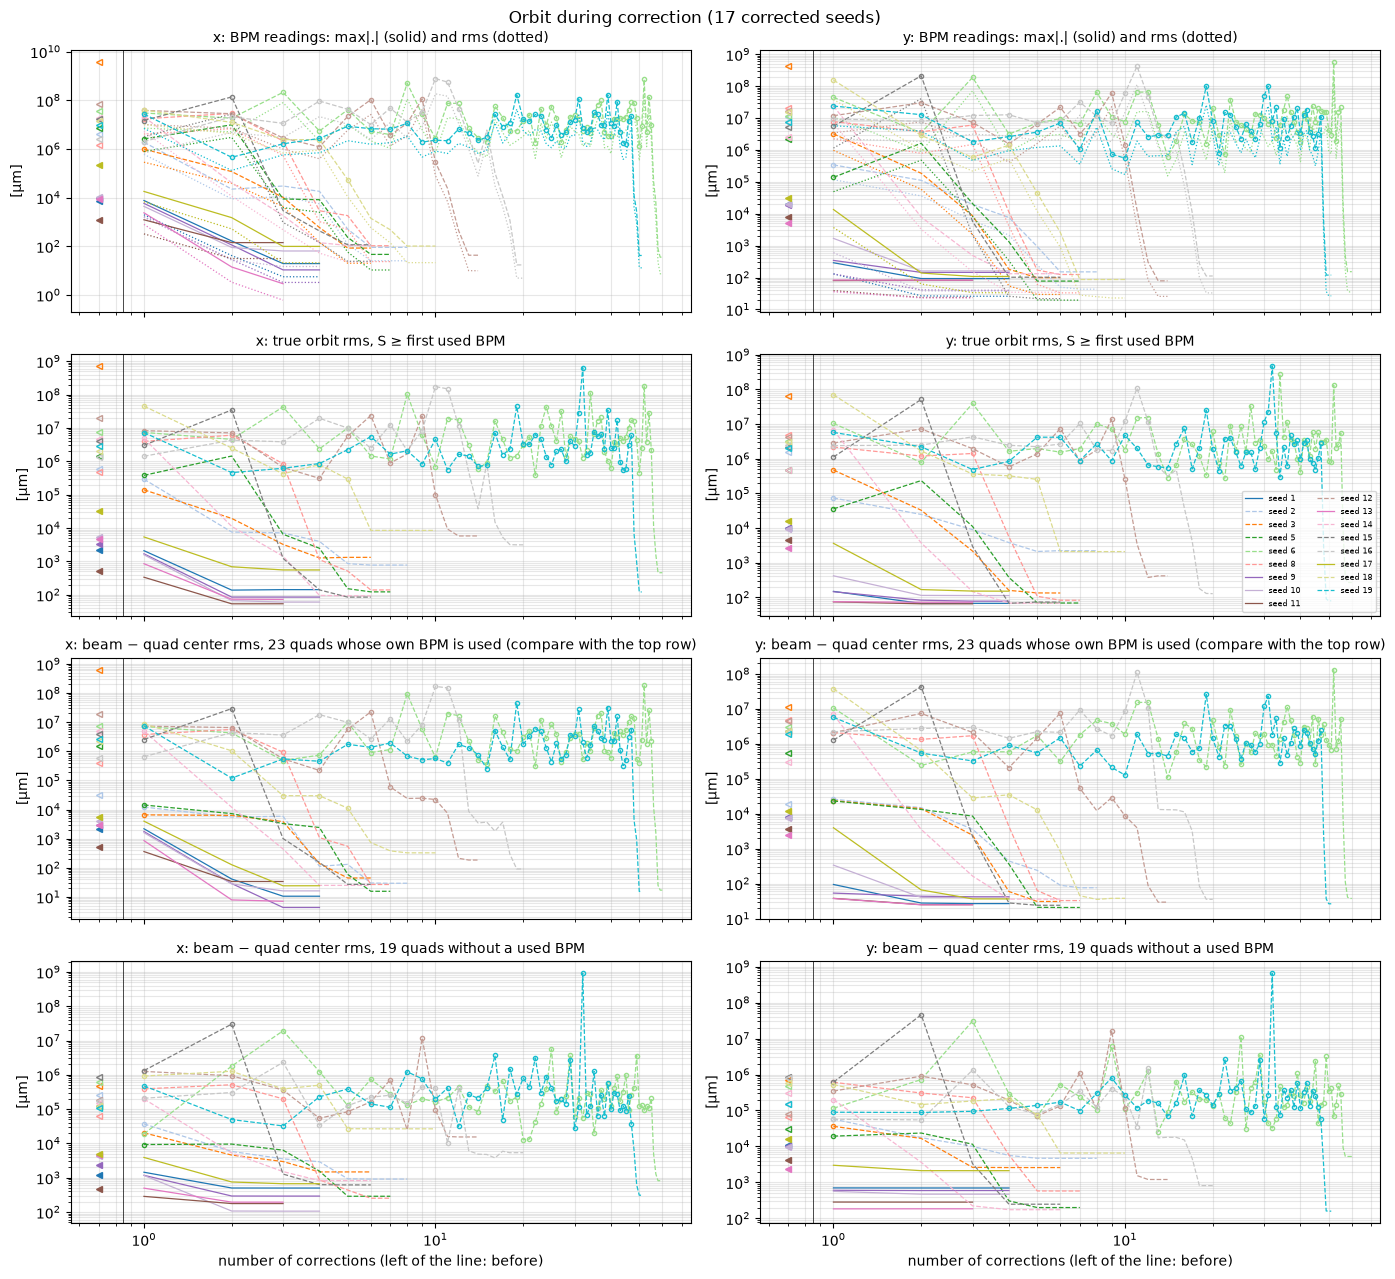

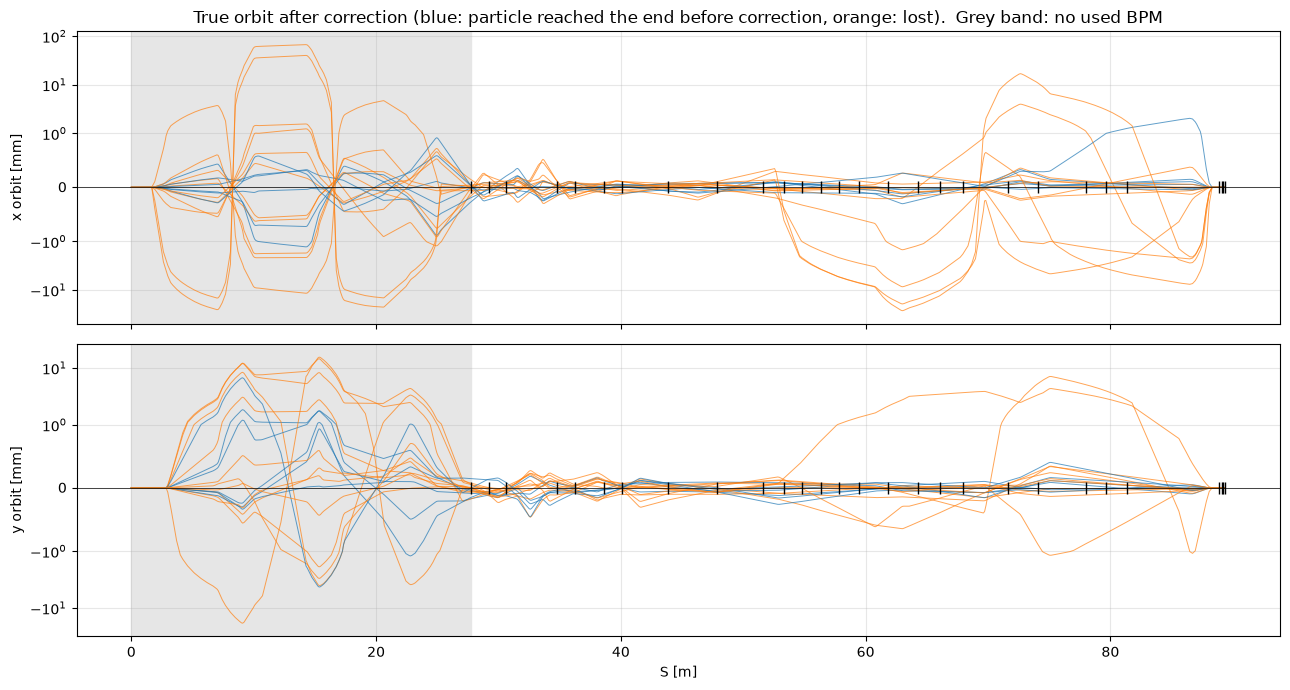

seed  steps |     true orbit rms [um]      | beam-quad rms [um]: own BPM used |    no BPM used     | particle before
            |   x down  y down x all y all |                x               y |         x        y |
   1      4 |      143      67   277   381 |             10.6            27.0 |     500.5    700.0 | reached
   2      8 |      778    2217   744  2946 |             29.6            76.9 |     914.7   4689.1 | lost
   3      6 |     1326     134  1172  1366 |             44.8            31.0 |    1476.1   2587.6 | lost
   5      7 |      123      69   169   112 |             15.7            20.9 |     288.3    199.8 | lost
   6     60 |      459     268   519  2818 |             17.2            37.9 |     817.2   5266.9 | lost
   8      7 |      140      83   168   291 |             26.8            32.9 |     252.6    577.2 | lost
   9      4 |       85      78   157   345 |              4.4            42.3 |     291.6    593.6 | reached
  10      4 |       61     113    

In [22]:
dn = ok_runs[0]['rec'][0]['orbit'][0] >= S_FIRST if ok_runs else None          # 最初の使う BPM より下流
own_q = np.array([('M' + q) in BPM_USE for q in QUADS_ON])                  # 自分の BPM を補正に使っている四重極
fig, axs = plt.subplots(4, 2, figsize=(14, 13), sharex=True)
for c, p in enumerate('xy'):
    for r, s in zip(ok_runs, OK_SEEDS):
        col, k = seed_col(s), np.arange(len(r['rec'])); alive = np.array([h['alive'] == 1 for h in r['rec']])
        ls = '--' if LOST0[s] else '-'
        for row, v, lsty in [(0, [np.abs(h['read'][c]).max() * 1e3 for h in r['rec']], ls), (0, [h['rms'][c] * 1e3 for h in r['rec']], ':'),
                             (1, [rms(h['orbit'][c + 1][dn]) * 1e3 for h in r['rec']], ls),
                             (2, [rms(np.asarray(h['bq'][c])[own_q]) * 1e3 for h in r['rec']], ls),
                             (3, [rms(np.asarray(h['bq'][c])[~own_q]) * 1e3 for h in r['rec']], ls)]:
            v = np.array(v); ax = axs[row, c]
            ax.loglog(k[1:], v[1:], lsty, lw=0.9, color=col, label=f'seed {s}' if (row, lsty) == (1, ls) else None)
            if lsty != ':':
                ax.loglog(k[1:][~alive[1:]], v[1:][~alive[1:]], 'o', ms=3, mfc='none', color=col)
                ax.loglog(0.7, v[0], '<', ms=5, color=col, mfc='none' if LOST0[s] else col)
    for row, lab in enumerate(['BPM readings: max|.| (solid) and rms (dotted)', 'true orbit rms, S ≥ first used BPM',
                               f'beam − quad center rms, {own_q.sum()} quads whose own BPM is used (compare with the top row)',
                               f'beam − quad center rms, {(~own_q).sum()} quads without a used BPM']):
        axs[row, c].set_title(f'{p}: {lab}', fontsize=10); axs[row, c].set_ylabel('[µm]'); axs[row, c].grid(alpha=0.3, which='both')
        axs[row, c].axvline(0.85, color='k', lw=0.5)
    axs[3, c].set_xlabel('number of corrections (left of the line: before)')
axs[1, 1].legend(fontsize=6, ncol=2)
fig.suptitle(f'Orbit during correction ({len(ok_runs)} corrected seeds)'); fig.tight_layout(); plt.show()

# 最後の真の軌道(重ねる)。縦軸は ±1 mm の内側が線形の符号つき対数
fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, j, p in [(axs[0], 1, 'x'), (axs[1], 2, 'y')]:
    for r, l0 in zip(ok_runs, lost0):
        o = r['rec'][-1]['orbit']; ax.plot(o[0], o[j], color='C1' if l0 else 'C0', lw=0.7, alpha=0.7)
    ax.axvspan(0, S_FIRST, color='0.9', zorder=0); ax.plot(S_USED, np.zeros(len(S_USED)), '|', color='k', ms=8)
    ax.set_yscale('symlog', linthresh=1); ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3); ax.set_ylabel(f'{p} orbit [mm]')
axs[0].set_title('True orbit after correction (blue: particle reached the end before correction, orange: lost).  Grey band: no used BPM')
axs[1].set_xlabel('S [m]'); fig.tight_layout(); plt.show()

print(f'{"seed":>4s} {"steps":>6s} | {"true orbit rms [um]":^28s} | {"beam-quad rms [um]: own BPM used":^32s} | {"no BPM used":^18s} | particle before')
print(f'{"":11s} | {"x down":>8s}{"y down":>8s}{"x all":>6s}{"y all":>6s} | {"x":>16s}{"y":>16s} | {"x":>9s}{"y":>9s} |')
for r, s in zip(ok_runs, OK_SEEDS):
    (S, ox, oy), (bx, by) = r['rec'][-1]['orbit'], r['rec'][-1]['bq']
    print(f'{s:4d} {len(r["rec"]) - 1:6d} | {rms(ox[dn])*1e3:8.0f}{rms(oy[dn])*1e3:8.0f}{rms(ox)*1e3:6.0f}{rms(oy)*1e3:6.0f} | '
          f'{rms(np.asarray(bx)[own_q])*1e3:16.1f}{rms(np.asarray(by)[own_q])*1e3:16.1f} | {rms(np.asarray(bx)[~own_q])*1e3:9.1f}{rms(np.asarray(by)[~own_q])*1e3:9.1f} | '
          f'{"lost" if LOST0[s] else "reached"}')

## 6.3 ノブ
上: ノブの値(その時点での設定の合計。ムーバーは据付位置からの移動量)を全 seed・全台まとめたヒストグラム(1, 2, 3 回目の後と最後)。途中では mm〜m 規模の値も出るので、横軸は符号つきの対数(|BL| < 0.01 T·mm、|移動量| < 1 µm が線形)。
下: ノブごとの最後の値(点 = seed、黒の横棒 = 青の seed の ± rms。縦軸は ±1 T·mm、±300 µm の内側が線形)。

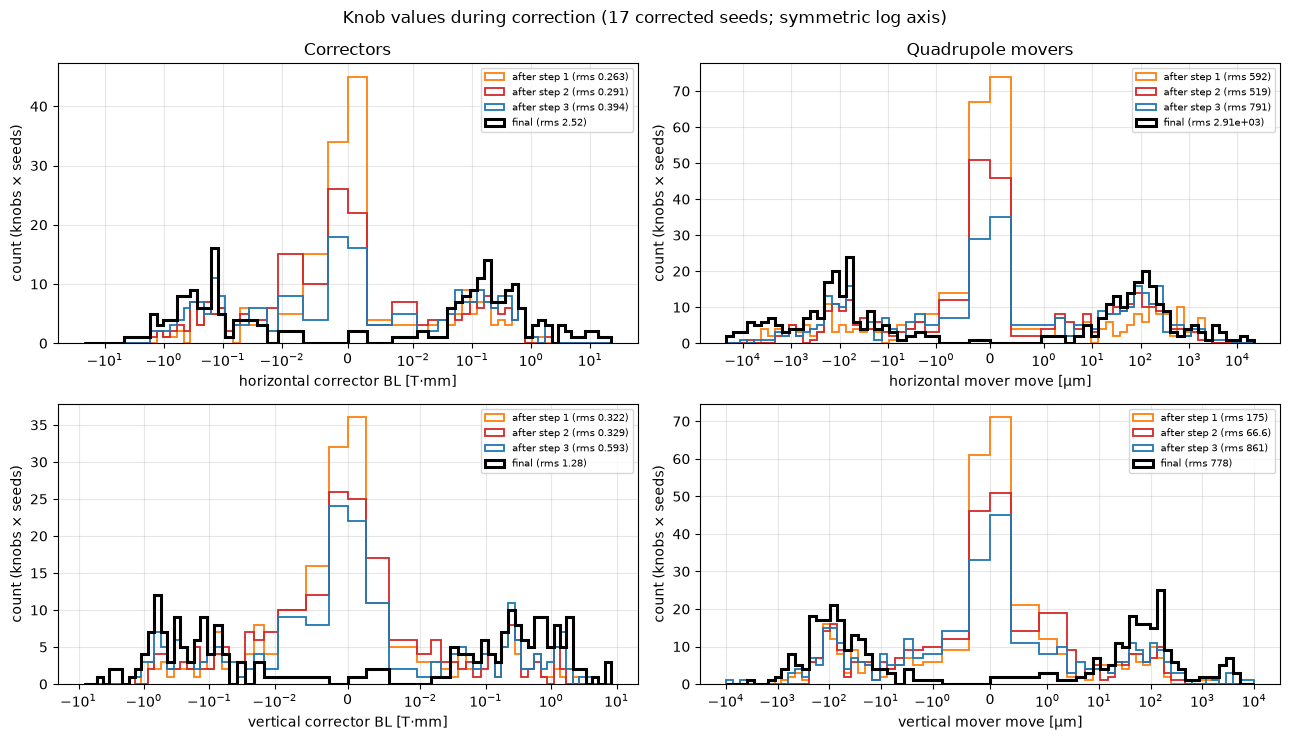

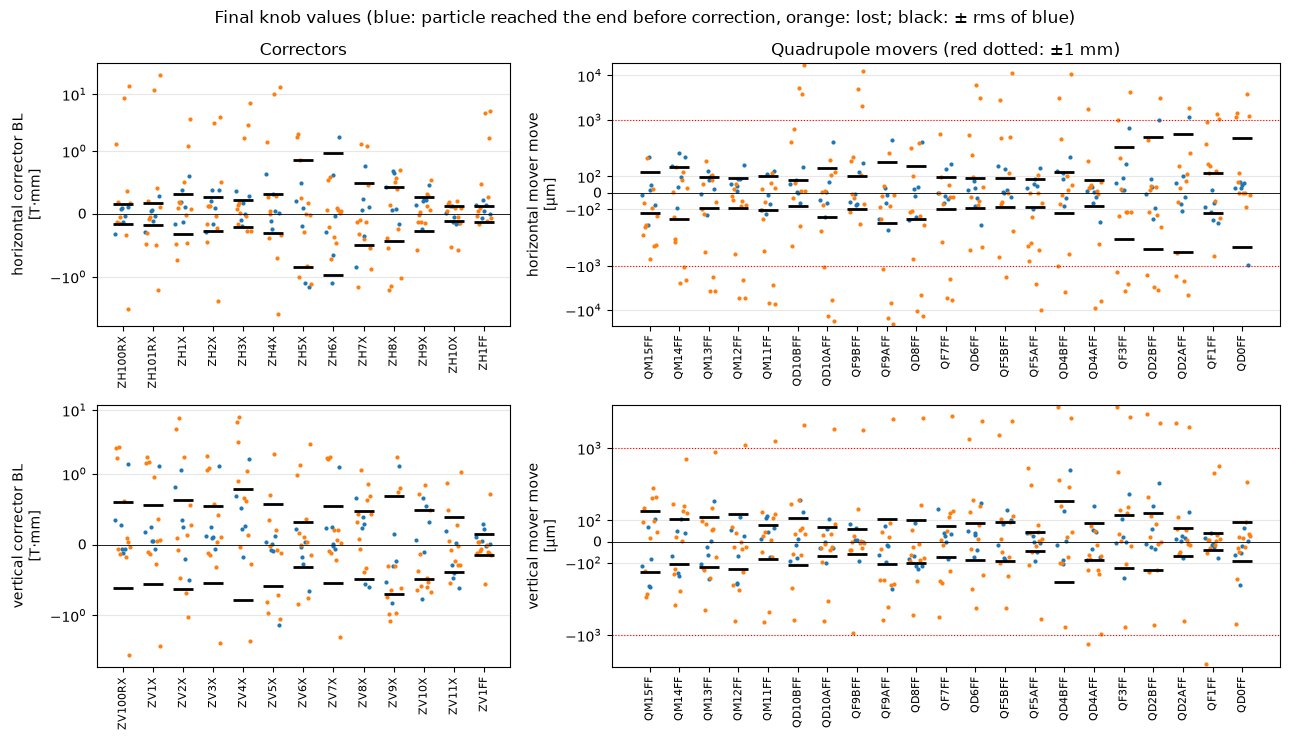

In [23]:
KN = [('cx', None, 'horizontal corrector BL [T·mm]', 1, 0.01), ('mv', 0, 'horizontal mover move [µm]', 1e3, 1),
      ('cy', None, 'vertical corrector BL [T·mm]',   1, 0.01), ('mv', 1, 'vertical mover move [µm]',   1e3, 1)]
knob = lambda h, key, j, sc: (h[key] if j is None else h[key][:, j]) * sc

def symlog_bins(vmax, c, n=61):
    """符号つき対数の横軸で、見た目が等間隔になるビンの境界(|v| < c は線形)"""
    t = np.linspace(-np.log10(1 + vmax / c), np.log10(1 + vmax / c), n)
    return np.sign(t) * c * (10**np.abs(t) - 1)

fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, (key, j, lab, sc, c) in zip(axs.ravel(), KN):
    sets = [(f'after step {k}', np.concatenate([knob(r['rec'][min(k, len(r['rec']) - 1)], key, j, sc) for r in ok_runs]), col)
            for k, col in [(1, 'C1'), (2, 'C3'), (3, 'C0')]]
    sets.append(('final', np.concatenate([knob(r['rec'][-1], key, j, sc) for r in ok_runs]), 'k'))
    bins = symlog_bins(max(np.abs(v).max() for _, v, _ in sets) * 1.05, c)
    for name, v, col in sets:
        ax.hist(v, bins=bins, histtype='step', lw=2.2 if col == 'k' else 1.3, color=col, label=f'{name} (rms {rms(v):.3g})')
    ax.set_xscale('symlog', linthresh=c); ax.set_xlabel(lab); ax.set_ylabel('count (knobs × seeds)'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axs[0, 0].set_title('Correctors'); axs[0, 1].set_title('Quadrupole movers')
fig.suptitle(f'Knob values during correction ({len(ok_runs)} corrected seeds; symmetric log axis)'); fig.tight_layout(); plt.show()

fig, axs = plt.subplots(2, 2, figsize=(13, 7.5), gridspec_kw={'width_ratios': [13, 21]})
for ax, (key, j, lab, sc, _), names in zip(axs.ravel(), KN, [CORRS_X, MOVERS, CORRS_Y, MOVERS]):
    pos = np.arange(len(names)); v = np.array([knob(r['rec'][-1], key, j, sc) for r in ok_runs]); jj = np.linspace(-0.25, 0.25, max(len(ok_runs), 2))[:len(ok_runs), None]
    ax.plot((pos + jj)[~lost0].T, v[~lost0].T, '.', color='C0', ms=4); ax.plot((pos + jj)[lost0].T, v[lost0].T, '.', color='C1', ms=4)
    if (~lost0).any():
        rv = np.sqrt(np.mean(v[~lost0]**2, axis=0)); ax.plot(pos, rv, '_', color='k', ms=14, mew=2); ax.plot(pos, -rv, '_', color='k', ms=14, mew=2)
    if sc != 1:
        ax.axhline(MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8); ax.axhline(-MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8)
    ax.set_yscale('symlog', linthresh=1 if sc == 1 else 300); ax.axhline(0, color='k', lw=0.6); ax.grid(alpha=0.3, axis='y')
    ax.set_ylabel(lab.replace(' [', '\n[')); ax.set_xticks(pos); ax.set_xticklabels(names, rotation=90, fontsize=8)
axs[0, 0].set_title('Correctors'); axs[0, 1].set_title(f'Quadrupole movers (red dotted: ±{MOVER_LIMIT_MM:g} mm)')
fig.suptitle('Final knob values (blue: particle reached the end before correction, orange: lost; black: ± rms of blue)'); fig.tight_layout(); plt.show()

## 6.4 四重極の最終位置と、ムーバーの動く範囲
- 最終位置(設計軸からのずれ)= 据付誤差 Δ + ムーバーの移動量。同じ架台に載った多極成分と BPM も同じだけずれている(BPM 自身の誤差 δ は別)。ムーバーの無い EXT の四重極(破線より左)は Δ のまま。
- seed ごとに、ムーバーのある四重極の最終位置(Δ + 移動量)を S の順に描く(2 枚目)。
- ムーバーの移動量が `MOVER_LIMIT_MM` を超える seed を、最後と途中(補正のすべての回の後)に分けてまとめる。(ヒートマップと推移の図は、**移動量**(Δ を含まない)で描いている)

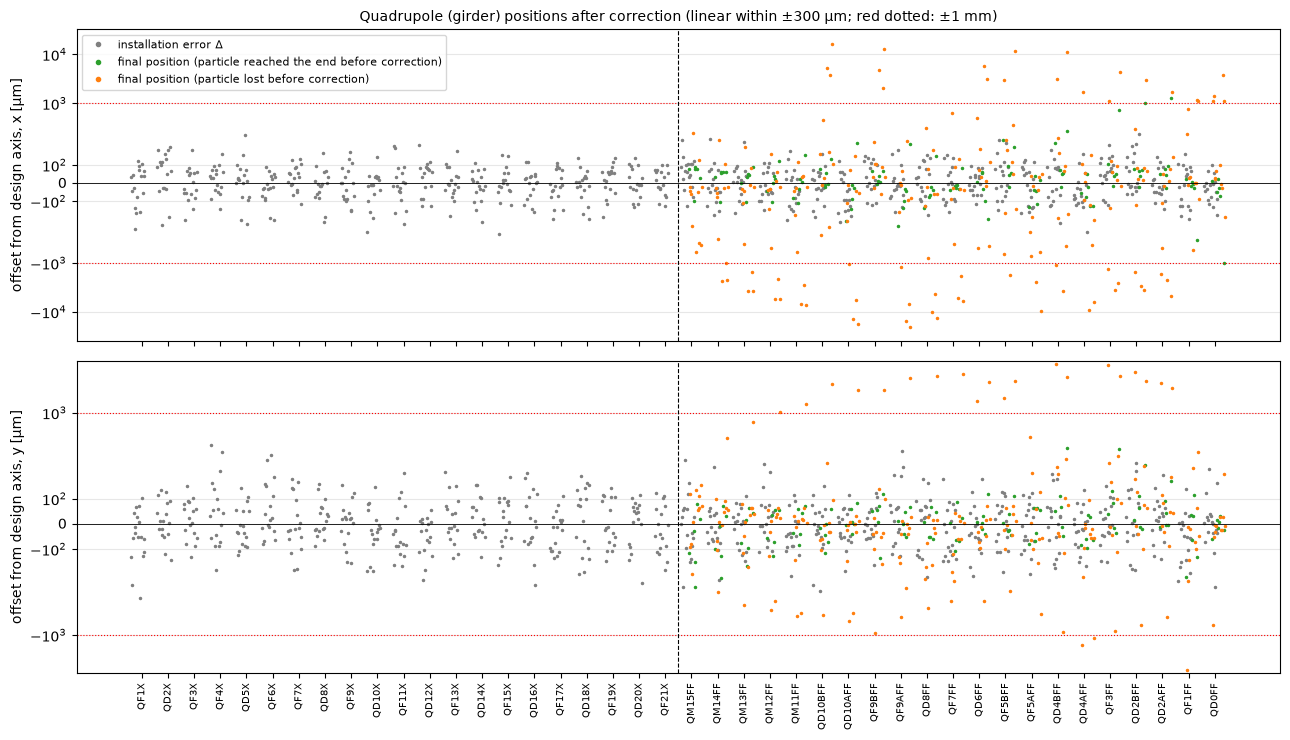

                                               rms over seeds and quads [um]                        
                             Δ x     Δ y   move x   move y  final x  final y  beam-quad x  beam-quad y
-- particle reached the end before correction: seeds [1, 9, 10, 11, 13, 17]
movers with own BPM (14)    94.2    99.4    218.9    114.6    216.7     92.2          4.9          2.8
movers without BPM  ( 7)    88.3    89.4    172.0     78.6    176.4     72.4        424.4        110.9
no mover (EXT)      (21)    94.0    95.1      0.0      0.0     94.0     95.1        265.5        922.9
-- particle lost before correction: seeds [2, 3, 5, 6, 8, 12, 14, 15, 16, 18, 19]
movers with own BPM (14)   104.1   101.0   3797.8   1070.4   3799.0   1062.0        150.2         27.2
movers without BPM  ( 7)    97.1   100.2   3236.5    704.1   3224.2    707.6       7427.5       1299.7
no mover (EXT)      (21)    94.3   102.3      0.0      0.0     94.3    102.3       7893.9       2798.9


In [24]:
hm = np.array([q in MOVERS for q in QUADS_ON]); own = np.array([('M' + q) in BPM_USE for q in QUADS_ON])
Dq = np.array([[r['D'][q] for q in QUADS_ON] for r in ok_runs]) * 1e3                                       # (seed, 四重極, 面) Δ [µm]
Mq = np.array([[r['rec'][-1]['mv'][MOVERS.index(q)] if q in MOVERS else np.zeros(2) for q in QUADS_ON] for r in ok_runs]) * 1e3
Fq = Dq + Mq                                                                                               # 最終位置 [µm]
BQq = np.array([r['rec'][-1]['bq'] for r in ok_runs]).transpose(0, 2, 1) * 1e3                            # ビーム − 磁場中心 [µm]

fig, axs = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
jj = np.linspace(-0.25, 0.25, max(len(ok_runs), 2))[:len(ok_runs), None]
for ax, j, p in [(axs[0], 0, 'x'), (axs[1], 1, 'y')]:
    ax.plot((np.arange(len(QUADS_ON)) + jj - 0.15).T, Dq[:, :, j].T, '.', color='gray', ms=3)
    ax.plot((np.flatnonzero(hm) + jj + 0.15)[~lost0].T, Fq[~lost0][:, hm, j].T, '.', color='C2', ms=3)
    ax.plot((np.flatnonzero(hm) + jj + 0.15)[lost0].T, Fq[lost0][:, hm, j].T, '.', color='C1', ms=3)
    ax.axhline(MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8); ax.axhline(-MOVER_LIMIT_MM * 1e3, color='r', ls=':', lw=0.8)
    ax.axvline(np.flatnonzero(hm)[0] - 0.5, color='k', lw=0.8, ls='--')
    ax.set_yscale('symlog', linthresh=300); ax.axhline(0, color='k', lw=0.6); ax.grid(alpha=0.3, axis='y'); ax.set_ylabel(f'offset from design axis, {p} [µm]')
axs[0].plot([], [], '.', color='gray', label='installation error Δ'); axs[0].plot([], [], '.', color='C2', label='final position (particle reached the end before correction)')
axs[0].plot([], [], '.', color='C1', label='final position (particle lost before correction)'); axs[0].legend(fontsize=8, loc='upper left')
axs[0].set_title(f'Quadrupole (girder) positions after correction (linear within ±300 µm; red dotted: ±{MOVER_LIMIT_MM:g} mm)', fontsize=10)
axs[1].set_xticks(np.arange(len(QUADS_ON))); axs[1].set_xticklabels(QUADS_ON, rotation=90, fontsize=7)
fig.tight_layout(); plt.show()

print(f'{"":24s}{"rms over seeds and quads [um]":^76s}')
print(f'{"":24s}{"Δ x":>8s}{"Δ y":>8s}{"move x":>9s}{"move y":>9s}{"final x":>9s}{"final y":>9s}{"beam-quad x":>13s}{"beam-quad y":>13s}')
for gname, g in [('particle reached the end before correction', ~lost0), ('particle lost before correction', lost0)]:
    if not g.any(): continue
    print(f'-- {gname}: seeds {[s for s, a in zip(OK_SEEDS, g) if a]}')
    for name, sel in [('movers with own BPM', hm & own), ('movers without BPM', hm & ~own), ('no mover (EXT)', ~hm)]:
        D, M, F, B = (A[g][:, sel] for A in (Dq, Mq, Fq, BQq))
        print(f'{name:20s}({sel.sum():2d}){rms(D[..., 0]):8.1f}{rms(D[..., 1]):8.1f}{rms(M[..., 0]):9.1f}{rms(M[..., 1]):9.1f}'
              f'{rms(F[..., 0]):9.1f}{rms(F[..., 1]):9.1f}{rms(B[..., 0]):13.1f}{rms(B[..., 1]):13.1f}')

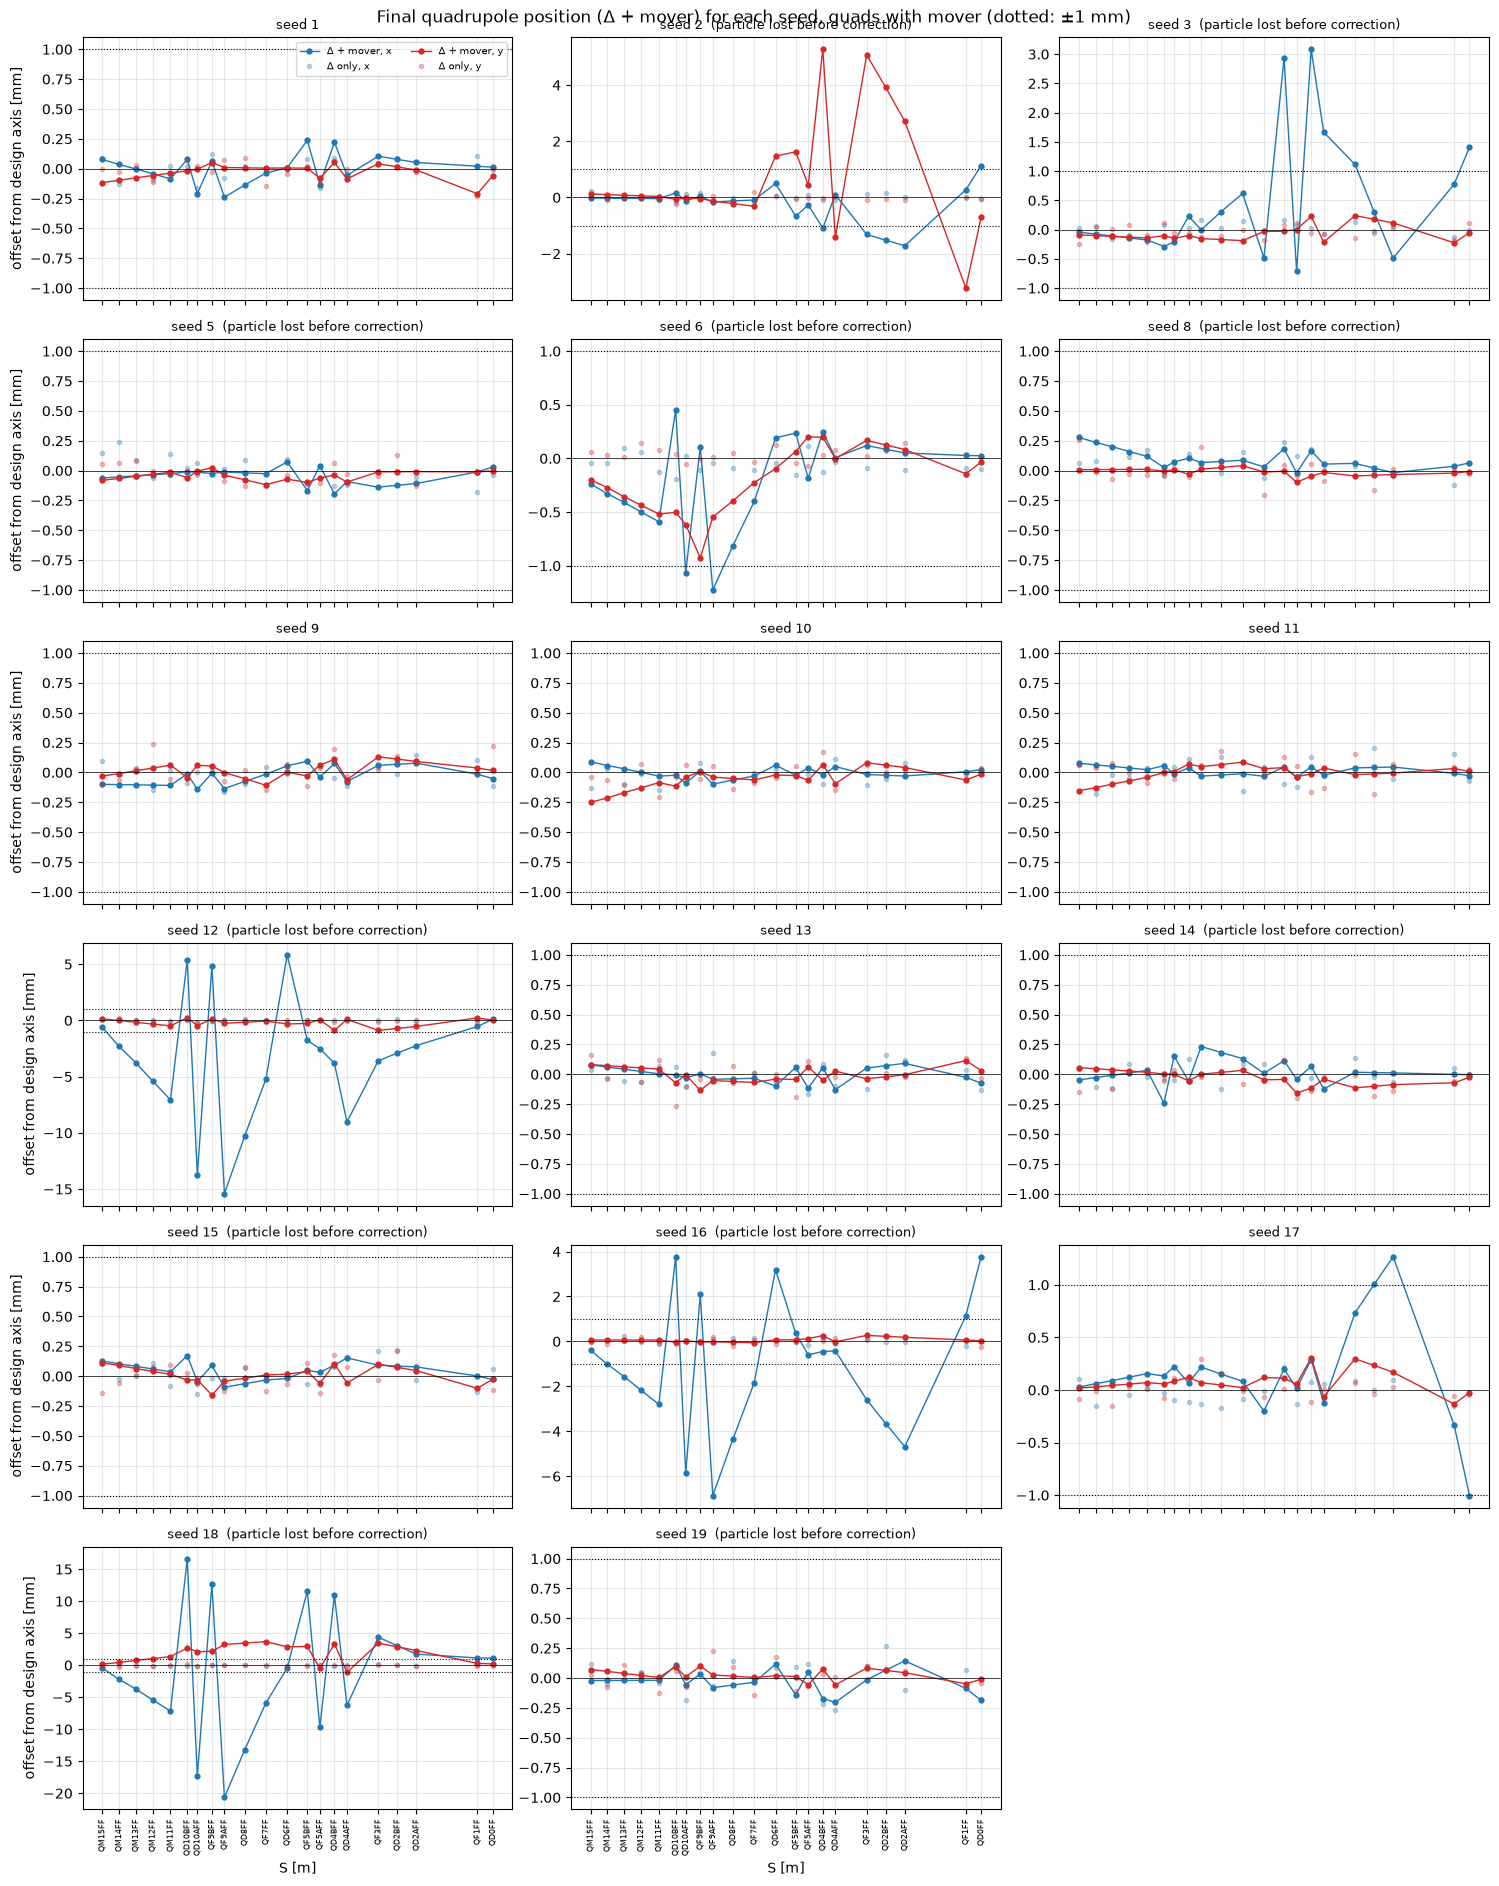

In [25]:
# seed ごとの四重極の最終位置(設計軸からのずれ = Δ + ムーバーの移動量)。横軸 = S(ムーバーのある四重極の範囲)
# 濃い線 = Δ + ムーバー、薄い点 = Δ だけ(補正前の位置)、点線 = ±MOVER_LIMIT_MM
S_mv = S_Q[hm]                                                                  # ムーバーのある四重極の S [m]
nc = 3; nr = int(np.ceil(len(ok_runs) / nc))
fig, axs = plt.subplots(nr, nc, figsize=(15, 3.2 * nr), sharex=True, squeeze=False)
for ax, i, s in zip(axs.ravel(), range(len(ok_runs)), OK_SEEDS):
    for j, col, p in [(0, 'C0', 'x'), (1, 'C3', 'y')]:
        ax.plot(S_mv, Fq[i, hm, j] * 1e-3, 'o-', ms=3.5, lw=1, color=col, label=f'Δ + mover, {p}')
        ax.plot(S_mv, Dq[i, hm, j] * 1e-3, 'o', ms=3, color=col, alpha=0.3, label=f'Δ only, {p}')
    for v in (MOVER_LIMIT_MM, -MOVER_LIMIT_MM):
        ax.axhline(v, color='k', ls=':', lw=0.8)
    ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3)
    ax.set_title(f'seed {s}' + ('  (particle lost before correction)' if LOST0[s] else ''), fontsize=9)
for ax in axs.ravel()[len(ok_runs):]:
    ax.axis('off')
for ax in axs[:, 0]:
    ax.set_ylabel('offset from design axis [mm]')
for ax in axs[-1]:
    ax.set_xticks(S_mv); ax.set_xticklabels([q for q in QUADS_ON if q in MOVERS], rotation=90, fontsize=6); ax.tick_params(labelbottom=True)
    ax.set_xlabel('S [m]')
axs[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle(f'Final quadrupole position (Δ + mover) for each seed, quads with mover (dotted: ±{MOVER_LIMIT_MM:g} mm)')
fig.tight_layout(); plt.show()

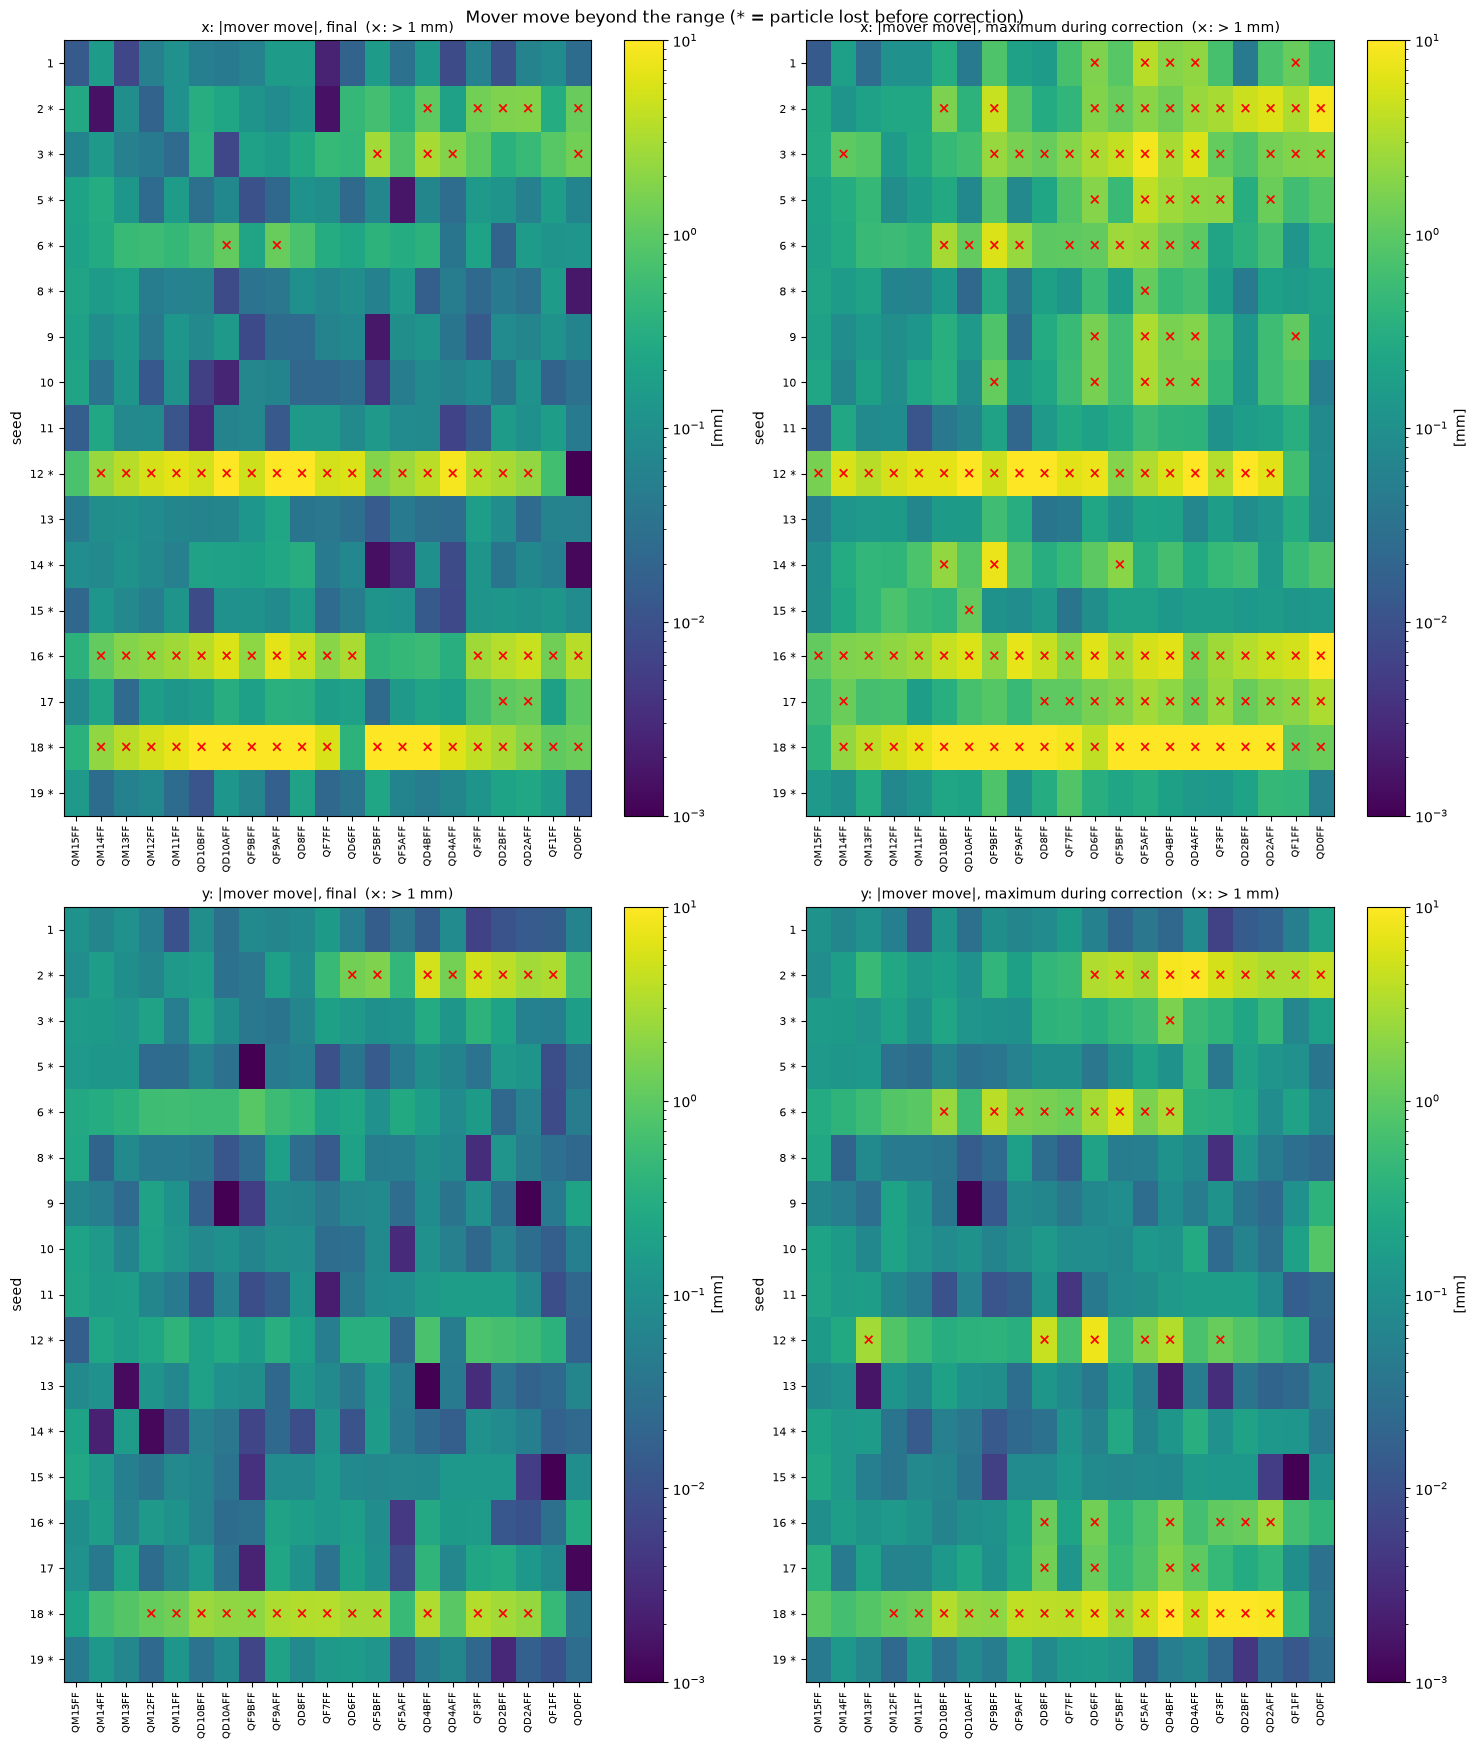

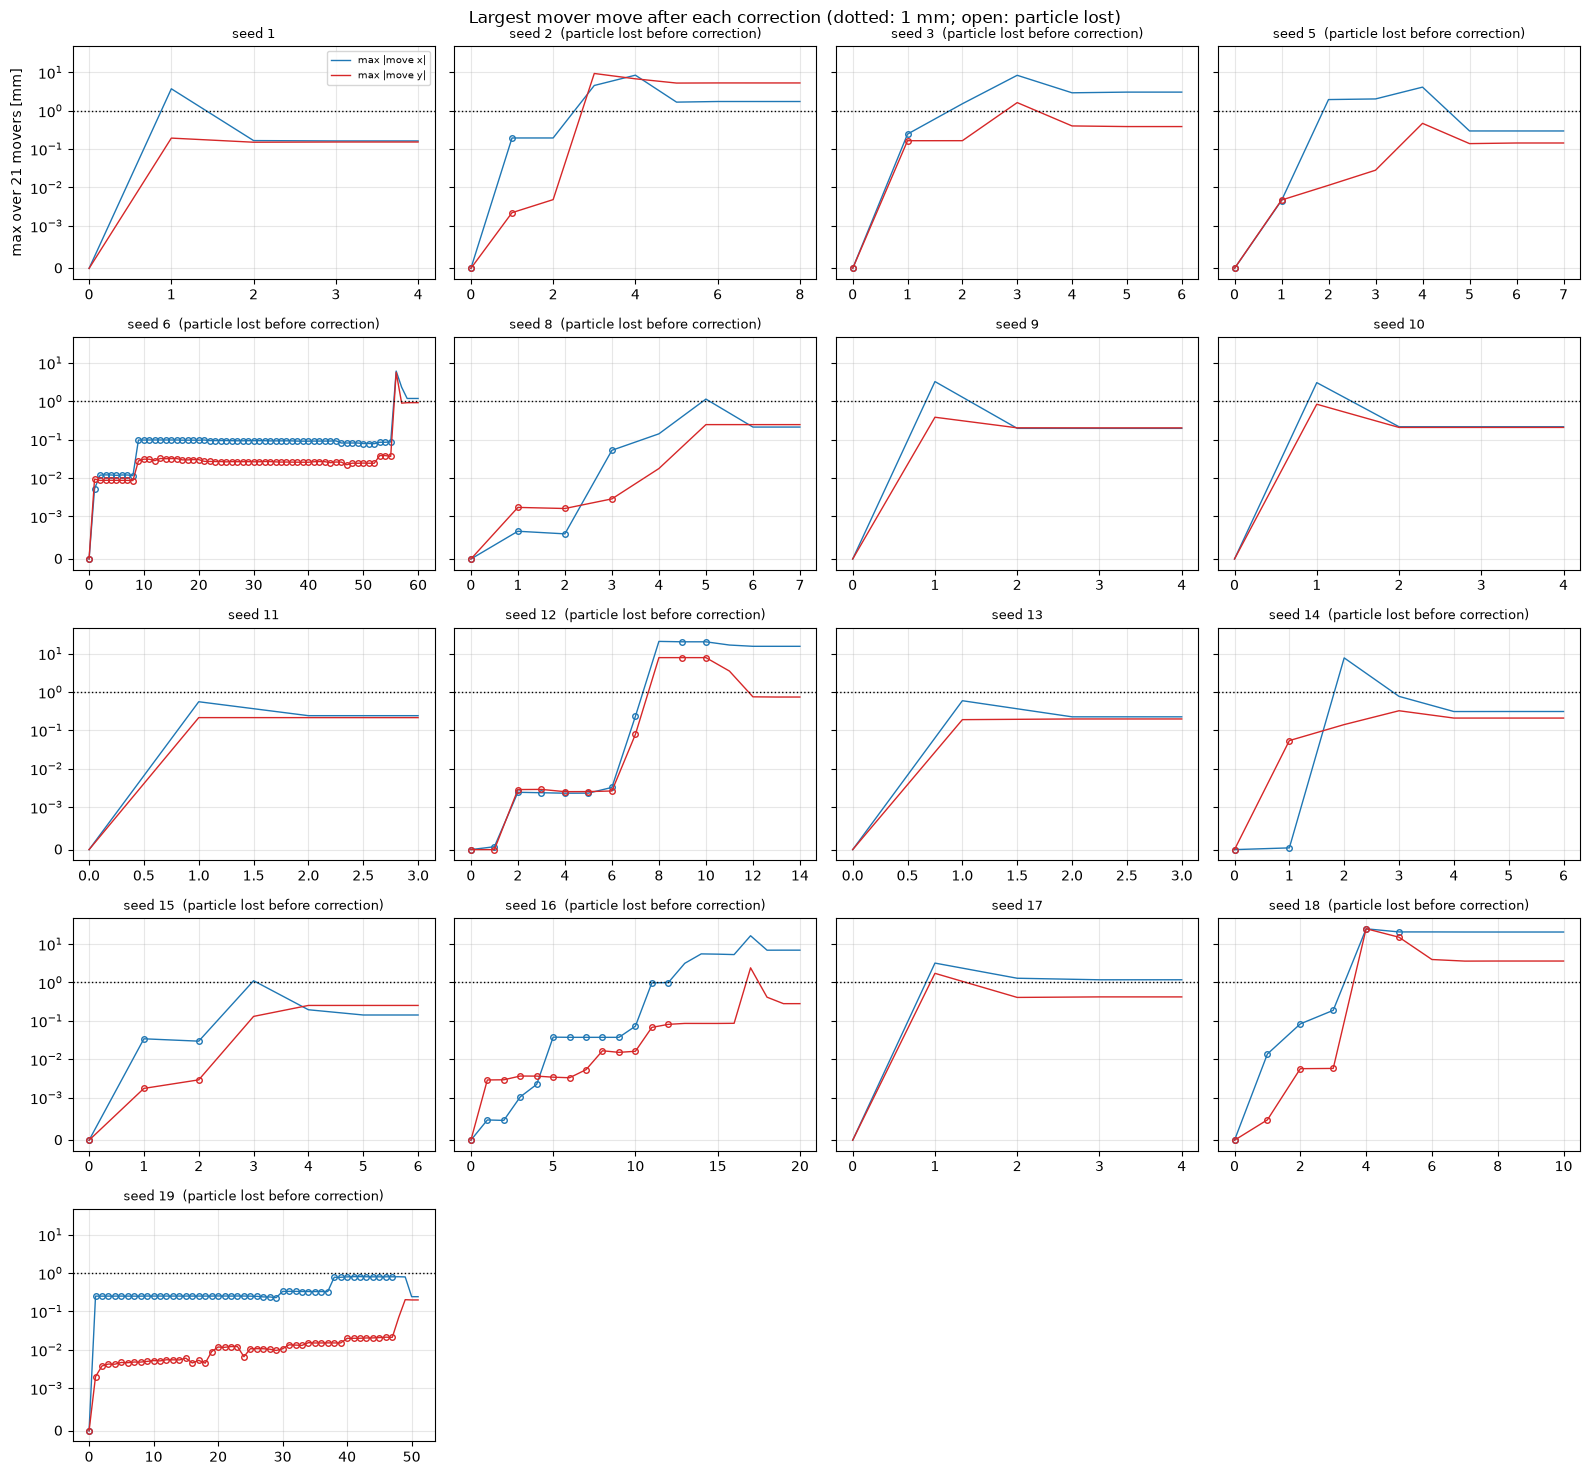

seed  part. | final: movers over   max|move| [mm] |        during: max|move| [mm]        | final max|Δ+move| [mm]
   1  reach |      x 0, y 0                  0.16 |     3.72 (QF5AFF x, after  1)   over |                   0.24
   2   lost |      x 5, y 8                  5.29 |     9.33 (QD4AFF y, after  3)   over |                   5.27
   3   lost |      x 4, y 0                  3.05 |     8.37 (QF5AFF x, after  3)   over |                   3.08
   5   lost |      x 0, y 0                  0.30 |     4.11 (QF5AFF x, after  4)   over |                   0.20
   6   lost |      x 2, y 0                  1.18 |     6.13 (QF9BFF x, after 56)   over |                   1.23
   8   lost |      x 0, y 0                  0.25 |     1.14 (QF5AFF x, after  5)   over |                   0.28
   9  reach |      x 0, y 0                  0.20 |     3.27 (QF5AFF x, after  1)   over |                   0.14
  10  reach |      x 0, y 0                  0.22 |     3.07 (QF5AFF x, after  1)   over

In [26]:
from matplotlib.colors import LogNorm
MVh = [np.array([h['mv'] for h in r['rec']]) for r in ok_runs]                  # seed ごと (回, 21, 2) 移動量 [mm]
fin_mv = np.array([m[-1] for m in MVh]); max_mv = np.array([np.abs(m).max(axis=0) for m in MVh])
fin_pos = np.array([fin_mv[i] + np.array([r['D'][q] for q in MOVERS]) for i, r in enumerate(ok_runs)])

fig, axs = plt.subplots(2, 2, figsize=(15, 2.5 + 0.45 * len(ok_runs) * 2))
ylab = [f'{s}' + (' *' if LOST0[s] else '') for s in OK_SEEDS]
for c, (A, ttl) in enumerate([(np.abs(fin_mv), 'final'), (max_mv, 'maximum during correction')]):
    for rr, (j, p) in enumerate([(0, 'x'), (1, 'y')]):
        ax = axs[rr, c]; im = ax.imshow(A[:, :, j], norm=LogNorm(vmin=1e-3, vmax=10), cmap='viridis', aspect='auto')
        for i, m in zip(*np.nonzero(A[:, :, j] > MOVER_LIMIT_MM)):
            ax.text(m, i, '×', ha='center', va='center', color='r', fontsize=11, fontweight='bold')
        ax.set_yticks(range(len(ylab))); ax.set_yticklabels(ylab, fontsize=8); ax.set_ylabel('seed')
        ax.set_xticks(range(len(MOVERS))); ax.set_xticklabels(MOVERS, rotation=90, fontsize=7)
        ax.set_title(f'{p}: |mover move|, {ttl}  (×: > {MOVER_LIMIT_MM:g} mm)', fontsize=10); fig.colorbar(im, ax=ax, label='[mm]')
fig.suptitle('Mover move beyond the range (* = particle lost before correction)'); fig.tight_layout(); plt.show()

nc = 4; nr = int(np.ceil(len(ok_runs) / nc))
fig, axs = plt.subplots(nr, nc, figsize=(16, 3 * nr), sharey=True, squeeze=False)
for ax, m, r, s in zip(axs.ravel(), MVh, ok_runs, OK_SEEDS):
    k = np.arange(len(m)); alive = np.array([h['alive'] == 1 for h in r['rec']])
    for j, col, p in [(0, 'C0', 'x'), (1, 'C3', 'y')]:
        v = np.abs(m[:, :, j]).max(axis=1)
        ax.plot(k, v, '-', color=col, lw=1, label=f'max |move {p}|'); ax.plot(k[~alive], v[~alive], 'o', color=col, ms=4, mfc='none')
    ax.axhline(MOVER_LIMIT_MM, color='k', ls=':', lw=1); ax.set_yscale('symlog', linthresh=1e-3); ax.grid(alpha=0.3, which='both')
    ax.set_title(f'seed {s}' + ('  (particle lost before correction)' if LOST0[s] else ''), fontsize=9)
for ax in axs.ravel()[len(ok_runs):]:
    ax.axis('off')
axs[0, 0].legend(fontsize=7); axs[0, 0].set_ylabel('max over 21 movers [mm]')
fig.suptitle(f'Largest mover move after each correction (dotted: {MOVER_LIMIT_MM:g} mm; open: particle lost)'); fig.tight_layout(); plt.show()

print(f'{"seed":>4s} {"part.":>6s} | {"final: movers over":^19s} {"max|move| [mm]":>15s} | {"during: max|move| [mm]":^36s} | {"final max|Δ+move| [mm]":>22s}')
for i, s in enumerate(OK_SEEDS):
    nf = (np.abs(fin_mv[i]) > MOVER_LIMIT_MM).sum(axis=0)
    jm, mm = np.unravel_index(np.argmax(max_mv[i].T), max_mv[i].T.shape); km = int(np.argmax(np.abs(MVh[i][:, mm, jm])))
    print(f'{s:4d} {"lost" if LOST0[s] else "reach":>6s} | {f"x {nf[0]}, y {nf[1]}":^19s} {np.abs(fin_mv[i]).max():15.2f} | '
          f'{max_mv[i].max():8.2f} ({MOVERS[mm]} {"xy"[jm]}, after {km:2d}) {"over" if max_mv[i].max() > MOVER_LIMIT_MM else "":>6s} | {np.abs(fin_pos[i]).max():22.2f}')
print()
for i, s in enumerate(OK_SEEDS):
    over = [f'{q} {"xy"[j]} {fin_mv[i, m, j]:+.2f}' for m, q in enumerate(MOVERS) for j in (0, 1) if abs(fin_mv[i, m, j]) > MOVER_LIMIT_MM]
    if over:
        print(f'seed {s:2d}: final move beyond {MOVER_LIMIT_MM:g} mm [mm]: ' + ', '.join(over))
print(f'\nwithin {MOVER_LIMIT_MM:g} mm at the end: {[s for i, s in enumerate(OK_SEEDS) if np.abs(fin_mv[i]).max() <= MOVER_LIMIT_MM]};  '
      f'during the whole correction: {[s for i, s in enumerate(OK_SEEDS) if max_mv[i].max() <= MOVER_LIMIT_MM]}')

# 7. メモ(σ = 100 µm、seed 1〜20、R を毎回測り直し、R は P1・読み値は B0 の設定で実行したときの値)
設定を変えて実行し直したら、ここは書き換える。
- 補正できたのは 20 seed 中 **17 seed**(補正の回数は中央値 6、最大 60)。補正できなかったのは seed 4, 7, 20。読み値を P1 で読んでいたとき(12 seed)より増えた。B0 では粒子の一部が届く回があり(seed 2 は補正前に 47%)、その重心の読み値で補正が進むためと考えられる(未確認)。
- 補正前から B0 の全粒子が届いていた 6 seed(1, 9, 10, 11, 13, 17)は 3〜4 回で補正できた(P1 で読んだときと同じ)。補正前に粒子が失われていた seed は、補正できてもノブと軌道が大きく外れた状態で止まるものが多い(seed 12, 18 はムーバーが 15〜21 mm)。
- 最後の B0 の読み値: MQM15FF より下流の 18 台は 0。上流の EXT の 10 台に最大 161 µm が残る(作れない方向。検証ノート A.8)。
- ムーバー: 最後の値で 1 mm を超えるのは 7 seed(2, 3, 6, 12, 16, 17, 18)。途中まで含めて 1 mm 以内に収まるのは 3 seed(11, 13, 19)。補正前から粒子が届いていた seed でも、1 回目に x のムーバーが 3〜4 mm 動いて 2 回目に戻る(seed 1, 9, 10, 17)。

## 確かめたいこと(検証は `orbit_correction_checks.ipynb` で行う)
- [ ] 粒子ロストの判定基準(保留中。ミーティングで確認)。今は RF-Track の判定(`get_ngood()`)だが、ラティスに開口が無いので、軌道が 100 mm〜m 規模になって計算が破綻するまで「生きている」扱いになる。候補: 全要素に開口を入れる(`set_aperture`、マニュアル 4 章)/ BPM の読み値が測れる範囲を超えたら使えない扱いにする.
- [ ] σ = 100 µm が現実的な大きさか(ミーティングで確認)。σ = 100 µm を一度に入れると、補正前の軌道は 20 seed すべてで 10 mm を超える
- [ ] ムーバーの動く範囲(約 1 mm)の確認
- [x] R が補正の前後で変わる理由 → 多極成分(A.7)
- [x] EXT の BPM に読み値が残る理由 → コレクタの位置(A.8)
- [x] 多極成分が 1 粒子にどう効くか(A.9)
- [ ] BPM の誤差 δ を入れたとき、最後の 4 台(直線区間)に読み値が残るか(A.8 の予想)
- [x] 読み値が 0 でもビーム − 磁場中心が 0 にならない理由 → BPM と四重極の中心が縦に約 0.12 m 離れている(A.10)
- [ ] 読み値を B0 にすると、補正できる seed が増えた(P1 で 12 → B0 で 17)理由(粒子の一部が届く回の、重心の読み値が効いているか)